# 09. Huella de voz: verificación por pares e identificación open-set

Este notebook conserva íntegramente la evaluación anterior de huella de voz:

- construcción de muestras audio-persona;
- pares genuine/impostor;
- calibración del umbral;
- AUC, EER, F1 y matrices de confusión;
- evaluación separada de agentes y clientes repetidos.

Además, añade una segunda evaluación complementaria:

- enrollment con llamadas históricas;
- consultas realizadas con llamadas no usadas en el perfil;
- identificación top-1;
- decisión `KNOWN` / `UNKNOWN`;
- perfiles operacionales reutilizables por el notebook de audios nuevos.

Los outputs anteriores mantienen **exactamente sus nombres y ubicación**. Los nuevos outputs se añaden en la misma carpeta con nombres diferentes. El notebook no mueve ni elimina resultados existentes.


In [1]:
# ============================================================
# CELDA 1 - IMPORTS
# ============================================================

from pathlib import Path
from itertools import combinations
import os
import json
import hashlib
import tempfile
from datetime import datetime, timezone
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.metrics import (
    roc_auc_score,
    roc_curve,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
)
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

print("Imports cargados correctamente.")

Imports cargados correctamente.


In [2]:
# ============================================================
# CELDA 2 - CONFIGURACIÓN DE RUTAS Y PARÁMETROS
# ============================================================

PROJECT_DIR = Path("/home/jupyter/TFM_ProcesadoDeAudios")

# Outputs del Notebook 01: embeddings vectoriales ya calculados
FINAL_RELABEL_DIR = PROJECT_DIR / "data" / "diarization_outputs" / "final_relabel"
EMBEDDING_VECTOR_DIR = FINAL_RELABEL_DIR / "embedding_vectors_csv"

# Outputs del Notebook 06: roles proxy AGENT / CLIENT
PROXY_OUTPUT_DIR = PROJECT_DIR / "data" / "proxy_groundtruth_outputs"

# Outputs del Notebook 05: transcripción segmentada, opcional para filtros de texto
TRANSCRIPTION_OUTPUT_DIR = PROJECT_DIR / "data" / "transcription_outputs"

# Salidas de este notebook
VOICEPRINT_DIR = PROJECT_DIR / "data" / "voiceprint_outputs"
FIGURES_DIR = VOICEPRINT_DIR / "figures"
CHECKPOINT_DIR = VOICEPRINT_DIR / "checkpoints"
for directory in [VOICEPRINT_DIR, FIGURES_DIR, CHECKPOINT_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

# Archivos esperados
SEGMENT_EMBEDDINGS_PATH = EMBEDDING_VECTOR_DIR / "all_segment_embeddings_vectors.csv"
ANCHOR_EMBEDDINGS_PATH = EMBEDDING_VECTOR_DIR / "all_anchor_embeddings_vectors.csv"
ROLE_MAPPING_PATH = PROXY_OUTPUT_DIR / "speaker_role_mapping_textual.csv"
SEGMENT_PROXY_PATH = PROXY_OUTPUT_DIR / "segment_level_proxy_groundtruth.csv"

# Candidatos de transcripción, por si el nombre cambia entre ejecuciones
TRANSCRIPTION_CANDIDATES = [
    TRANSCRIPTION_OUTPUT_DIR / "06_transcribed_segments_final.csv",
    TRANSCRIPTION_OUTPUT_DIR / "all_segments_transcribed.csv",
    TRANSCRIPTION_OUTPUT_DIR / "transcribed_segments_final.csv",
]

# Filtros de calidad para segmentos de voz
MIN_SEGMENT_DURATION_SEC = 1.50
MAX_SEGMENT_DURATION_SEC = 20.00
MAX_OVERLAP_RATIO = 0.05
MIN_RMS_DBFS = -40.0
MIN_WORDS_PER_SEGMENT = 0  # 0 = no exige texto, porque la huella se basa en voz

# Construcción de muestras por identidad
MIN_SEGMENTS_PER_AUDIO_PERSON = 1
MIN_SECONDS_PER_AUDIO_PERSON = 1.50
MIN_SAMPLES_PER_IDENTITY = 2
MIN_TOTAL_SECONDS_PER_IDENTITY = 10

# Split por identidad
AGENT_TEST_SIZE = 0.30
USE_CLIENTS_IN_CALIBRATION = False

# Pares de verificación
MAX_POSITIVE_PAIRS_PER_IDENTITY = 500
NEGATIVE_MULTIPLIER = 3
MAX_NEGATIVE_PAIRS = 200_000

# Umbral principal: se calibra en agentes de calibración
THRESHOLD_STRATEGY = "youden"  # opciones: "youden" o "eer"


# ------------------------------------------------------------
# Checkpoints locales + GCS
# ------------------------------------------------------------
FORCE_REBUILD = True
RESTORE_FROM_GCS = True
UPLOAD_TO_GCS = True

# Bucket y prefijo de outputs del proyecto.
# No son secretos y no dependen del archivo .env.
GCS_BUCKET_NAME = "catedras_audio_detection"
GCS_PROJECT_PREFIX = "pipelineA/procesados_UNAV/voiceprint_outputs"

# ------------------------------------------------------------
# Parámetros adicionales para enrollment e identificación open-set
# ------------------------------------------------------------
OPEN_SET_MIN_SAMPLES_PER_IDENTITY = 3
OPEN_SET_MIN_TOTAL_SECONDS_PER_IDENTITY = 10.0
MIN_ENROLLMENT_SAMPLES = 2
MIN_QUERY_SAMPLES = 1
QUERY_FRACTION = 0.30

UNKNOWN_IDENTITY_FRACTION = 0.20
TEST_KNOWN_IDENTITY_FRACTION = 0.30
MIN_IDENTITIES_FOR_FORMAL_OPEN_SET = 6
OPEN_SET_THRESHOLD_STRATEGY = "eer"

BUILD_CLIENT_PROFILES = True
EMBEDDING_MODEL_LABEL = "embedding_precalculado_notebook_01"
NOTEBOOK_VERSION = "09_voiceprint_pairwise_open_set_v3"

print("PROJECT_DIR:", PROJECT_DIR)
print("Embeddings:", SEGMENT_EMBEDDINGS_PATH)
print("Roles proxy:", ROLE_MAPPING_PATH)
print("Salidas:", VOICEPRINT_DIR)
print(
    "Destino GCS:",
    f"gs://{GCS_BUCKET_NAME}/{GCS_PROJECT_PREFIX}/",
)

PROJECT_DIR: /home/jupyter/TFM_ProcesadoDeAudios
Embeddings: /home/jupyter/TFM_ProcesadoDeAudios/data/diarization_outputs/final_relabel/embedding_vectors_csv/all_segment_embeddings_vectors.csv
Roles proxy: /home/jupyter/TFM_ProcesadoDeAudios/data/proxy_groundtruth_outputs/speaker_role_mapping_textual.csv
Salidas: /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs
Destino GCS: gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/


## Checkpoints locales y GCS

Todos los CSV, JSON y gráficos se escriben primero de forma segura en local y después se suben a la misma ruta relativa de GCS. Un archivo existente con el mismo nombre se sobrescribe; no se elimina ni mueve ningún otro output.


In [3]:
# ============================================================
# CELDA 3 - UTILIDADES DE CHECKPOINT LOCAL + GCS
# ============================================================

_GCS_CLIENT = None


def utc_now_iso() -> str:
    return datetime.now(timezone.utc).isoformat()


def get_gcs_client():
    """Crea el cliente una sola vez. Requiere autenticación disponible en la VM."""
    global _GCS_CLIENT

    if not GCS_BUCKET_NAME:
        raise ValueError(
            "GCS_BUCKET_NAME está vacío. Define TFM_GCS_BUCKET en la VM "
            "o escribe el nombre del bucket en la celda de configuración."
        )

    if _GCS_CLIENT is None:
        from google.cloud import storage
        _GCS_CLIENT = storage.Client()

    return _GCS_CLIENT


def local_path_to_gcs_blob(local_path: Path) -> str:
    """Conserva la estructura relativa a voiceprint_outputs en GCS."""
    local_path = Path(local_path).resolve()

    try:
        relative = local_path.relative_to(VOICEPRINT_DIR.resolve())
    except ValueError:
        relative = Path("external_checkpoints") / local_path.name

    return f"{GCS_PROJECT_PREFIX}/{relative.as_posix()}".strip("/")


def upload_file_to_gcs(local_path: Path, overwrite: bool = True) -> str | None:
    """
    Función única de subida, deliberadamente genérica para poder compartirla
    después entre todos los notebooks.
    """
    local_path = Path(local_path)

    if not UPLOAD_TO_GCS:
        return None

    if not GCS_BUCKET_NAME:
        print(f"[GCS-SKIP] Bucket no configurado: {local_path.name}")
        return None

    client = get_gcs_client()
    bucket = client.bucket(GCS_BUCKET_NAME)
    blob_name = local_path_to_gcs_blob(local_path)
    blob = bucket.blob(blob_name)

    if blob.exists(client) and not overwrite:
        uri = f"gs://{GCS_BUCKET_NAME}/{blob_name}"
        print(f"[GCS-EXISTS] {uri}")
        return uri

    blob.upload_from_filename(str(local_path))
    uri = f"gs://{GCS_BUCKET_NAME}/{blob_name}"
    print(f"[GCS-UPLOAD] {uri}")
    return uri


def upload_directory_to_gcs(local_dir: Path) -> list[str]:
    """Sube recursivamente todos los archivos existentes de una carpeta."""
    local_dir = Path(local_dir)

    if not local_dir.exists():
        return []

    uploaded = []

    for local_path in sorted(local_dir.rglob("*")):
        if not local_path.is_file():
            continue

        uri = upload_file_to_gcs(local_path)

        if uri is not None:
            uploaded.append(uri)

    return uploaded


def download_file_from_gcs(local_path: Path, overwrite: bool = False) -> bool:
    """Restaura el checkpoint esperado usando la misma ruta relativa."""
    local_path = Path(local_path)

    if local_path.exists() and not overwrite:
        return True

    if not RESTORE_FROM_GCS or not GCS_BUCKET_NAME:
        return False

    client = get_gcs_client()
    bucket = client.bucket(GCS_BUCKET_NAME)
    blob_name = local_path_to_gcs_blob(local_path)
    blob = bucket.blob(blob_name)

    if not blob.exists(client):
        return False

    local_path.parent.mkdir(parents=True, exist_ok=True)
    blob.download_to_filename(str(local_path))
    print(f"[GCS-DOWNLOAD] gs://{GCS_BUCKET_NAME}/{blob_name}")
    return True


def ensure_local_checkpoint(local_path: Path) -> bool:
    local_path = Path(local_path)
    return local_path.exists() or download_file_from_gcs(local_path)


def atomic_write_dataframe(df: pd.DataFrame, path: Path) -> None:
    """Evita interpretar como válido un CSV escrito parcialmente."""
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    with tempfile.NamedTemporaryFile(
        mode="w",
        suffix=".tmp",
        prefix=f"{path.stem}_",
        dir=path.parent,
        delete=False,
        encoding="utf-8",
        newline="",
    ) as tmp:
        tmp_path = Path(tmp.name)

    try:
        df.to_csv(tmp_path, index=False)
        tmp_path.replace(path)
    finally:
        tmp_path.unlink(missing_ok=True)


def atomic_write_json(payload: dict, path: Path) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    with tempfile.NamedTemporaryFile(
        mode="w",
        suffix=".tmp",
        prefix=f"{path.stem}_",
        dir=path.parent,
        delete=False,
        encoding="utf-8",
    ) as tmp:
        json.dump(payload, tmp, indent=2, ensure_ascii=False, default=str)
        tmp_path = Path(tmp.name)

    try:
        tmp_path.replace(path)
    finally:
        tmp_path.unlink(missing_ok=True)


def save_dataframe_checkpoint(df: pd.DataFrame, path: Path, upload: bool = True) -> Path:
    atomic_write_dataframe(df, path)
    if upload:
        upload_file_to_gcs(path)
    print(f"[CHECKPOINT] {path} | {len(df):,} filas")
    return path


def save_json_checkpoint(payload: dict, path: Path, upload: bool = True) -> Path:
    atomic_write_json(payload, path)
    if upload:
        upload_file_to_gcs(path)
    print(f"[CHECKPOINT] {path}")
    return path


def load_dataframe_checkpoint(path: Path) -> pd.DataFrame | None:
    if not FORCE_REBUILD and ensure_local_checkpoint(path):
        df = pd.read_csv(path)
        print(f"[CHECKPOINT-LOAD] {path.name}: {len(df):,} filas")
        return df
    return None


def save_figure_checkpoint(fig, path: Path) -> Path:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    fig.savefig(path, dpi=160, bbox_inches="tight")
    upload_file_to_gcs(path)
    print(f"[FIGURE] {path}")
    return path


## 1. Funciones auxiliares

In [4]:
# ============================================================
# CELDA 3 - FUNCIONES AUXILIARES DE CARGA Y NORMALIZACIÓN
# ============================================================

def read_csv_required(path: Path, name: str) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"No existe {name}: {path}")
    df = pd.read_csv(path)
    print(f"{name}: {df.shape[0]:,} filas | {df.shape[1]:,} columnas")
    return df


def read_first_existing(candidates, name: str, required: bool = False) -> pd.DataFrame:
    for p in candidates:
        if Path(p).exists():
            df = pd.read_csv(p)
            print(f"{name}: {df.shape[0]:,} filas | {df.shape[1]:,} columnas | {p.name}")
            return df
    if required:
        raise FileNotFoundError(f"No se encontró archivo para {name}. Candidatos: {candidates}")
    print(f"{name}: no disponible")
    return pd.DataFrame()


def get_embedding_columns(df: pd.DataFrame):
    return sorted([c for c in df.columns if c.startswith("emb_")])


def normalize_audio_key(value):
    if pd.isna(value):
        return np.nan
    value = str(value).strip()
    return Path(value).stem


def choose_existing_col(df: pd.DataFrame, candidates, required=False, label="columna"):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise ValueError(f"No se encontró {label}. Candidatas: {candidates}. Columnas: {list(df.columns)[:50]}")
    return None


def add_time_key(df: pd.DataFrame, start_col="start", end_col="end", decimals=3):
    df = df.copy()
    if start_col in df.columns and end_col in df.columns:
        df["time_key"] = (
            df[start_col].astype(float).round(decimals).astype(str)
            + "_"
            + df[end_col].astype(float).round(decimals).astype(str)
        )
    return df


def stable_hash_dict(payload: dict) -> str:
    """Genera un hash reproducible de una configuración serializable."""
    serialized = json.dumps(
        payload,
        sort_keys=True,
        ensure_ascii=False,
        default=str,
    )
    return hashlib.sha256(serialized.encode("utf-8")).hexdigest()


def l2_normalize_matrix(X):
    X = np.asarray(X, dtype=np.float32)
    norms = np.linalg.norm(X, axis=1, keepdims=True)
    norms[norms <= 1e-12] = 1.0
    return X / norms


def cosine_similarity_matrix(X, Y):
    """Calcula la similitud coseno entre todas las filas de X y Y."""
    X_norm = l2_normalize_matrix(X)
    Y_norm = l2_normalize_matrix(Y)
    return X_norm @ Y_norm.T


def cosine_from_normalized(a, b):
    return float(np.dot(a, b))

In [5]:
# ============================================================
# CELDA 4 - FUNCIONES DE PARES, UMBRAL, MÉTRICAS Y GRÁFICOS
# ============================================================

def build_verification_pairs(
    df_samples: pd.DataFrame,
    emb_cols,
    max_positive_pairs_per_identity=MAX_POSITIVE_PAIRS_PER_IDENTITY,
    negative_multiplier=NEGATIVE_MULTIPLIER,
    max_negative_pairs=MAX_NEGATIVE_PAIRS,
    random_state=RANDOM_SEED,
):
    # Cada fila de df_samples representa una muestra audio-persona.
    rng = np.random.default_rng(random_state)
    df = df_samples.reset_index(drop=True).copy()

    if df.empty or df["person_id"].nunique() < 2:
        return pd.DataFrame()

    X = l2_normalize_matrix(df[emb_cols].values)
    person_values = df["person_id"].astype(str).values
    role_values = df["role_proxy"].astype(str).values if "role_proxy" in df.columns else np.array(["UNKNOWN"] * len(df))
    sample_ids = df["sample_id"].astype(str).values
    audio_values = df["audio_key"].astype(str).values if "audio_key" in df.columns else np.array([""] * len(df))

    rows = []

    # Positivos: misma identidad. Se priorizan audios distintos.
    for person_id, idxs in df.groupby("person_id").indices.items():
        idxs = list(idxs)
        if len(idxs) < 2:
            continue

        all_pairs = [(i, j) for i, j in combinations(idxs, 2) if audio_values[i] != audio_values[j]]
        if len(all_pairs) == 0:
            all_pairs = list(combinations(idxs, 2))

        if len(all_pairs) > max_positive_pairs_per_identity:
            chosen_idx = rng.choice(len(all_pairs), size=max_positive_pairs_per_identity, replace=False)
            all_pairs = [all_pairs[k] for k in chosen_idx]

        for i, j in all_pairs:
            rows.append({
                "sample_id_a": sample_ids[i],
                "sample_id_b": sample_ids[j],
                "person_id_a": person_values[i],
                "person_id_b": person_values[j],
                "role_a": role_values[i],
                "role_b": role_values[j],
                "audio_a": audio_values[i],
                "audio_b": audio_values[j],
                "same_identity": 1,
                "similarity": cosine_from_normalized(X[i], X[j]),
            })

    n_pos = len(rows)
    if n_pos == 0:
        return pd.DataFrame(rows)

    # Negativos: identidades distintas. Se muestrea para evitar explosión combinatoria.
    target_neg = min(max_negative_pairs, n_pos * negative_multiplier)
    neg_rows = []
    attempts = 0
    max_attempts = max(target_neg * 20, 10_000)

    while len(neg_rows) < target_neg and attempts < max_attempts:
        attempts += 1
        i, j = rng.choice(len(df), size=2, replace=False)
        if person_values[i] == person_values[j]:
            continue
        neg_rows.append({
            "sample_id_a": sample_ids[i],
            "sample_id_b": sample_ids[j],
            "person_id_a": person_values[i],
            "person_id_b": person_values[j],
            "role_a": role_values[i],
            "role_b": role_values[j],
            "audio_a": audio_values[i],
            "audio_b": audio_values[j],
            "same_identity": 0,
            "similarity": cosine_from_normalized(X[i], X[j]),
        })

    rows.extend(neg_rows)
    return pd.DataFrame(rows)


def compute_eer_threshold(y_true, scores):
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    fnr = 1 - tpr
    idx = int(np.nanargmin(np.abs(fpr - fnr)))
    eer = float((fpr[idx] + fnr[idx]) / 2)
    threshold = float(thresholds[idx])
    return eer, threshold, fpr, tpr, thresholds


def choose_threshold_from_pairs(df_pairs, strategy="youden"):
    y_true = df_pairs["same_identity"].astype(int).values
    scores = df_pairs["similarity"].astype(float).values
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    fnr = 1 - tpr

    if strategy == "eer":
        idx = int(np.nanargmin(np.abs(fpr - fnr)))
    else:
        idx = int(np.nanargmax(tpr - fpr))

    eer_idx = int(np.nanargmin(np.abs(fpr - fnr)))

    return {
        "threshold": float(thresholds[idx]),
        "strategy": strategy,
        "eer": float((fpr[eer_idx] + fnr[eer_idx]) / 2),
        "eer_threshold": float(thresholds[eer_idx]),
        "fpr": fpr,
        "tpr": tpr,
        "thresholds": thresholds,
    }


def evaluate_pairs(df_pairs, threshold=None, label="dataset"):
    if df_pairs is None or df_pairs.empty:
        return {
            "dataset": label,
            "n_pairs": 0,
            "n_positive": 0,
            "n_negative": 0,
            "auc": np.nan,
            "eer": np.nan,
            "threshold": threshold,
            "accuracy": np.nan,
            "precision": np.nan,
            "recall": np.nan,
            "f1": np.nan,
        }

    y_true = df_pairs["same_identity"].astype(int).values
    scores = df_pairs["similarity"].astype(float).values

    if len(np.unique(y_true)) < 2:
        auc = np.nan
        eer = np.nan
    else:
        auc = float(roc_auc_score(y_true, scores))
        eer, _, _, _, _ = compute_eer_threshold(y_true, scores)

    if threshold is None:
        threshold = choose_threshold_from_pairs(df_pairs, strategy=THRESHOLD_STRATEGY)["threshold"] if len(np.unique(y_true)) == 2 else np.nan

    if pd.isna(threshold):
        accuracy = precision = recall = f1 = np.nan
    else:
        y_pred = (scores >= threshold).astype(int)
        accuracy = float(accuracy_score(y_true, y_pred))
        precision = float(precision_score(y_true, y_pred, zero_division=0))
        recall = float(recall_score(y_true, y_pred, zero_division=0))
        f1 = float(f1_score(y_true, y_pred, zero_division=0))

    return {
        "dataset": label,
        "n_pairs": int(len(df_pairs)),
        "n_positive": int((y_true == 1).sum()),
        "n_negative": int((y_true == 0).sum()),
        "auc": auc,
        "eer": eer,
        "threshold": threshold,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
    }


def plot_similarity_distribution(df_pairs, title, output_path=None):
    if df_pairs is None or df_pairs.empty:
        print("No hay pares para graficar:", title)
        return
    plt.figure(figsize=(8, 5))
    df_pos = df_pairs[df_pairs["same_identity"] == 1]
    df_neg = df_pairs[df_pairs["same_identity"] == 0]
    if not df_neg.empty:
        plt.hist(df_neg["similarity"], bins=40, alpha=0.6, label="Impostor")
    if not df_pos.empty:
        plt.hist(df_pos["similarity"], bins=40, alpha=0.6, label="Genuine")
    plt.title(title)
    plt.xlabel("Similitud coseno")
    plt.ylabel("Número de pares")
    plt.legend()
    plt.grid(True, alpha=0.3)
    if output_path is not None:
        plt.savefig(output_path, dpi=160, bbox_inches="tight")
        upload_file_to_gcs(output_path)
    plt.show()


def plot_roc_curve(df_pairs, title, output_path=None):
    if df_pairs is None or df_pairs.empty or df_pairs["same_identity"].nunique() < 2:
        print("No hay clases suficientes para ROC:", title)
        return
    y_true = df_pairs["same_identity"].astype(int).values
    scores = df_pairs["similarity"].astype(float).values
    fpr, tpr, _ = roc_curve(y_true, scores)
    auc = roc_auc_score(y_true, scores)
    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Azar")
    plt.title(title)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid(True, alpha=0.3)
    if output_path is not None:
        plt.savefig(output_path, dpi=160, bbox_inches="tight")
        upload_file_to_gcs(output_path)
    plt.show()

## 2. Carga de embeddings, roles proxy y transcripciones

In [6]:
# ============================================================
# CELDA 5 - CARGA DE INPUTS PRINCIPALES
# ============================================================

# Embeddings de segmentos generados por Notebook 01 corregido
df_embeddings = read_csv_required(SEGMENT_EMBEDDINGS_PATH, "Embeddings de segmentos")

# Mapping speaker_final -> AGENT / CLIENT generado por Notebook 06 corregido
df_role_mapping = read_csv_required(ROLE_MAPPING_PATH, "Mapping speaker-rol proxy")

# Proxy segment-level opcional, útil para auditoría
if SEGMENT_PROXY_PATH.exists():
    df_segment_proxy = pd.read_csv(SEGMENT_PROXY_PATH)
    print(f"Proxy por segmento: {df_segment_proxy.shape[0]:,} filas | {df_segment_proxy.shape[1]:,} columnas")
else:
    df_segment_proxy = pd.DataFrame()
    print("Proxy por segmento: no disponible")

# Transcripción opcional para métricas de palabras/texto.
df_transcriptions = read_first_existing(TRANSCRIPTION_CANDIDATES, "Transcripción segmentada", required=False)

emb_cols = get_embedding_columns(df_embeddings)
print("\nColumnas de embedding detectadas:", len(emb_cols))

if len(emb_cols) == 0:
    raise ValueError("No se detectaron columnas emb_0000, emb_0001, etc. Revisa el output del Notebook 01.")

print("Dimensión vectorial:", len(emb_cols))
display(df_embeddings.head(3))
display(df_role_mapping.head(3))

Embeddings de segmentos: 43,493 filas | 278 columnas
Mapping speaker-rol proxy: 2,332 filas | 31 columnas
Proxy por segmento: 40,352 filas | 49 columnas
Transcripción segmentada: 40,352 filas | 55 columnas | 06_transcribed_segments_final.csv

Columnas de embedding detectadas: 256
Dimensión vectorial: 256


,segment_id_raw,audio_file,audio_stem,start,end,duration,speaker,rms_dbfs,overlap_duration_sec,overlap_ratio,...,emb_0246,emb_0247,emb_0248,emb_0249,emb_0250,emb_0251,emb_0252,emb_0253,emb_0254,emb_0255
0,1,raw_9154117451310006851_clean.wav,raw_9154117451310006851_clean,0.030969,4.452219,4.421250,SPEAKER_01,-28.919975,0.0,0.0,...,0.030611,0.022685,-0.006958,-0.019831,-0.076800,0.029375,0.054193,-0.001175,-0.040470,-0.040619
1,2,raw_9154117451310006851_clean.wav,raw_9154117451310006851_clean,5.211594,6.342219,1.130625,SPEAKER_00,-33.883114,0.0,0.0,...,0.000107,-0.053748,-0.006796,0.081271,-0.076451,-0.051200,-0.017624,0.035729,0.097657,-0.082482
2,3,raw_9154117451310006851_clean.wav,raw_9154117451310006851_clean,6.426594,13.800969,7.374375,SPEAKER_01,-29.186810,0.0,0.0,...,0.018454,0.037934,-0.011938,-0.067195,-0.056253,-0.000533,0.061380,-0.043470,-0.026707,-0.044090


,audio_file,speaker_final,probable_role,n_matches_role,n_matches_total,role_confidence,mean_combined_score,mean_char_cosine,score_vs_agent,score_vs_client,...,first_evidence_start,last_evidence_end,evidence_status,evidence_text_preview,role_mapping_status,role_assignment_method,agent_hash,customer_hash,brand_ds,duration_min
0,raw_9154117451310006851_clean.wav,SPEAKER_01,AGENT,NaN,4,0.472210,0.821495,0.792328,0.821495,0.349284,...,6.426594,137.747844,sufficient_evidence,no hace falta que llames porque está la incide...,accepted_speaker_role,aggregated_speaker_text_one_to_one,143be6589a2896d9,a9caf51c656e2261,ORANGE,2.93
1,raw_9154117451310006851_clean.wav,SPEAKER_00,CLIENT,NaN,7,0.220715,0.636368,0.575693,0.415653,0.636368,...,5.211594,164.055969,sufficient_evidence,Y yo viajando ahí trabajando el viernes y... V...,accepted_speaker_role,aggregated_speaker_text_one_to_one,143be6589a2896d9,a9caf51c656e2261,ORANGE,2.93
2,raw_9154117551220006851_clean.wav,SPEAKER_00,AGENT,NaN,3,0.229119,0.546611,0.577310,0.546611,0.317492,...,106.107219,165.760344,sufficient_evidence,"Claro, o la subimos y si quieres yo te lo hago...",accepted_speaker_role,aggregated_speaker_text_one_to_one,022ea603159275cd,73e95b4635bee260,ORANGE,3.29


In [7]:
# ============================================================
# CELDA 6 - NORMALIZACIÓN DE CLAVES Y COLUMNAS DE ROL
# ============================================================

# Normalizar embeddings
df_embeddings = df_embeddings.copy()

if "audio_file" not in df_embeddings.columns and "audio_stem" in df_embeddings.columns:
    df_embeddings["audio_file"] = df_embeddings["audio_stem"].astype(str) + ".wav"

if "audio_stem" not in df_embeddings.columns and "audio_file" in df_embeddings.columns:
    df_embeddings["audio_stem"] = df_embeddings["audio_file"].apply(normalize_audio_key)

df_embeddings["audio_key"] = df_embeddings["audio_file"].apply(normalize_audio_key)

speaker_col_emb = choose_existing_col(
    df_embeddings,
    ["speaker_final", "speaker_relabel", "speaker", "label"],
    required=True,
    label="speaker en embeddings",
)

if speaker_col_emb != "speaker_final":
    df_embeddings["speaker_final"] = df_embeddings[speaker_col_emb]

# Normalizar mapping de roles
df_role_mapping = df_role_mapping.copy()

if "audio_file" not in df_role_mapping.columns and "audio_stem" in df_role_mapping.columns:
    df_role_mapping["audio_file"] = df_role_mapping["audio_stem"].astype(str) + ".wav"

if "audio_stem" not in df_role_mapping.columns and "audio_file" in df_role_mapping.columns:
    df_role_mapping["audio_stem"] = df_role_mapping["audio_file"].apply(normalize_audio_key)

df_role_mapping["audio_key"] = df_role_mapping["audio_file"].apply(normalize_audio_key)

role_col_mapping = choose_existing_col(
    df_role_mapping,
    ["probable_role", "assigned_role", "official_role_proxy", "role_proxy", "role"],
    required=True,
    label="rol proxy en mapping",
)

if role_col_mapping != "role_proxy":
    df_role_mapping["role_proxy"] = df_role_mapping[role_col_mapping]

speaker_col_mapping = choose_existing_col(
    df_role_mapping,
    ["speaker_final", "speaker", "speaker_label"],
    required=True,
    label="speaker en mapping",
)

if speaker_col_mapping != "speaker_final":
    df_role_mapping["speaker_final"] = df_role_mapping[speaker_col_mapping]

# Mantener columnas necesarias del mapping
mapping_cols = [
    "audio_key",
    "audio_file",
    "speaker_final",
    "role_proxy",
    "role_confidence",
    "proxy_confidence",
    "role_mapping_status",
    "agent_hash",
    "customer_hash",
    "brand_ds",
    "duration_min",
]
mapping_cols = [c for c in mapping_cols if c in df_role_mapping.columns]

df_role_mapping_small = (
    df_role_mapping[mapping_cols]
    .drop_duplicates(subset=["audio_key", "speaker_final"], keep="first")
    .copy()
)

print("Speaker usado en embeddings:", speaker_col_emb)
print("Rol usado en mapping:", role_col_mapping)
print("Filas mapping únicas audio-speaker:", len(df_role_mapping_small))
display(df_role_mapping_small.head())

Speaker usado en embeddings: speaker_final
Rol usado en mapping: probable_role
Filas mapping únicas audio-speaker: 2332


,audio_key,audio_file,speaker_final,role_proxy,role_confidence,role_mapping_status,agent_hash,customer_hash,brand_ds,duration_min
0,raw_9154117451310006851_clean,raw_9154117451310006851_clean.wav,SPEAKER_01,AGENT,0.472210,accepted_speaker_role,143be6589a2896d9,a9caf51c656e2261,ORANGE,2.93
1,raw_9154117451310006851_clean,raw_9154117451310006851_clean.wav,SPEAKER_00,CLIENT,0.220715,accepted_speaker_role,143be6589a2896d9,a9caf51c656e2261,ORANGE,2.93
2,raw_9154117551220006851_clean,raw_9154117551220006851_clean.wav,SPEAKER_00,AGENT,0.229119,accepted_speaker_role,022ea603159275cd,73e95b4635bee260,ORANGE,3.29
3,raw_9154117551220006851_clean,raw_9154117551220006851_clean.wav,SPEAKER_01,CLIENT,0.070341,accepted_speaker_role,022ea603159275cd,73e95b4635bee260,ORANGE,3.29
4,raw_9154152155960016851_clean,raw_9154152155960016851_clean.wav,SPEAKER_01,AGENT,0.408522,accepted_speaker_role,5c196bda72500462,87ac862422b770da,ORANGE,2.91


In [8]:
# ============================================================
# CELDA 7 - UNIÓN DE EMBEDDINGS CON ROLES PROXY
# ============================================================

# Merge principal: cada segmento con embedding hereda el rol proxy del speaker en ese audio.
df_voice_segments = df_embeddings.merge(
    df_role_mapping_small,
    on=["audio_key", "speaker_final"],
    how="left",
    suffixes=("", "_mapping"),
)

# Resolver rol y person_id
df_voice_segments["role_proxy"] = df_voice_segments["role_proxy"].astype(str).str.upper().str.strip()

df_voice_segments["person_id"] = np.where(
    df_voice_segments["role_proxy"].eq("AGENT"),
    df_voice_segments.get("agent_hash"),
    np.where(
        df_voice_segments["role_proxy"].eq("CLIENT"),
        df_voice_segments.get("customer_hash"),
        np.nan,
    ),
)

# Métricas opcionales de transcripción: n_words/status.
if not df_transcriptions.empty:
    df_t = df_transcriptions.copy()
    if "audio_file" not in df_t.columns and "audio_stem" in df_t.columns:
        df_t["audio_file"] = df_t["audio_stem"].astype(str) + ".wav"
    df_t["audio_key"] = df_t["audio_file"].apply(normalize_audio_key)
    df_voice_segments = add_time_key(df_voice_segments, "start", "end")
    df_t = add_time_key(df_t, "start", "end")

    t_cols = ["audio_key", "time_key", "speaker_final", "n_words", "n_chars", "transcription_status"]
    t_cols = [c for c in t_cols if c in df_t.columns]

    if {"audio_key", "time_key"}.issubset(t_cols):
        merge_keys = ["audio_key", "time_key"]
        if "speaker_final" in t_cols and "speaker_final" in df_voice_segments.columns:
            merge_keys.append("speaker_final")
        df_voice_segments = df_voice_segments.merge(
            df_t[t_cols].drop_duplicates(subset=merge_keys),
            on=merge_keys,
            how="left",
            suffixes=("", "_transcription"),
        )

# Resumen de cobertura
print("Segmentos con embeddings:", len(df_embeddings))
print("Segmentos con rol proxy unido:", df_voice_segments["role_proxy"].isin(["AGENT", "CLIENT"]).sum())
print("Segmentos con person_id:", df_voice_segments["person_id"].notna().sum())
print("Audios con roles:", df_voice_segments.loc[df_voice_segments["person_id"].notna(), "audio_key"].nunique())

coverage = (
    df_voice_segments
    .assign(has_person=df_voice_segments["person_id"].notna())
    .groupby("role_proxy", dropna=False)
    .agg(
        n_segments=("audio_key", "size"),
        n_with_person=("has_person", "sum"),
        n_audios=("audio_key", "nunique"),
        n_persons=("person_id", "nunique"),
    )
    .reset_index()
)
display(coverage)
display(df_voice_segments.head(3))

Segmentos con embeddings: 43493
Segmentos con rol proxy unido: 42978
Segmentos con person_id: 42758
Audios con roles: 1166


,role_proxy,n_segments,n_with_person,n_audios,n_persons
0,AGENT,22413,22413,1166,462
1,CLIENT,20565,20345,1166,1026
2,NAN,515,0,15,0


,segment_id_raw,audio_file,audio_stem,start,end,duration,speaker,rms_dbfs,overlap_duration_sec,overlap_ratio,...,role_proxy,role_confidence,role_mapping_status,agent_hash,customer_hash,brand_ds,duration_min,person_id,time_key,transcription_status
0,1,raw_9154117451310006851_clean.wav,raw_9154117451310006851_clean,0.030969,4.452219,4.421250,SPEAKER_01,-28.919975,0.0,0.0,...,AGENT,0.472210,accepted_speaker_role,143be6589a2896d9,a9caf51c656e2261,ORANGE,2.93,143be6589a2896d9,0.031_4.452,ok
1,2,raw_9154117451310006851_clean.wav,raw_9154117451310006851_clean,5.211594,6.342219,1.130625,SPEAKER_00,-33.883114,0.0,0.0,...,CLIENT,0.220715,accepted_speaker_role,143be6589a2896d9,a9caf51c656e2261,ORANGE,2.93,a9caf51c656e2261,5.212_6.342,ok
2,3,raw_9154117451310006851_clean.wav,raw_9154117451310006851_clean,6.426594,13.800969,7.374375,SPEAKER_01,-29.186810,0.0,0.0,...,AGENT,0.472210,accepted_speaker_role,143be6589a2896d9,a9caf51c656e2261,ORANGE,2.93,143be6589a2896d9,6.427_13.801,ok


## 3. Dataset base para huella de voz

In [9]:
# ============================================================
# CELDA 8 - FILTROS DE CALIDAD PARA SEGMENTOS DE HUELLA
# ============================================================

df_vp = df_voice_segments.copy()

# Asegurar columnas numéricas
for c in ["duration", "overlap_ratio", "rms_dbfs", "n_words"]:
    if c in df_vp.columns:
        df_vp[c] = pd.to_numeric(df_vp[c], errors="coerce")

mask = pd.Series(True, index=df_vp.index)
mask &= df_vp["role_proxy"].isin(["AGENT", "CLIENT"])
mask &= df_vp["person_id"].notna()

if "duration" in df_vp.columns:
    mask &= df_vp["duration"].between(MIN_SEGMENT_DURATION_SEC, MAX_SEGMENT_DURATION_SEC, inclusive="both")

if "overlap_ratio" in df_vp.columns:
    mask &= df_vp["overlap_ratio"].fillna(0) <= MAX_OVERLAP_RATIO

if "rms_dbfs" in df_vp.columns:
    mask &= df_vp["rms_dbfs"].fillna(-999) >= MIN_RMS_DBFS

if "valid_export" in df_vp.columns:
    valid_export = df_vp["valid_export"]
    if valid_export.dtype == object:
        valid_export = valid_export.astype(str).str.lower().isin(["true", "1", "yes", "ok"])
    mask &= valid_export.fillna(False).astype(bool)

if MIN_WORDS_PER_SEGMENT > 0 and "n_words" in df_vp.columns:
    mask &= df_vp["n_words"].fillna(0) >= MIN_WORDS_PER_SEGMENT

df_voiceprint_segments = df_vp[mask].copy().reset_index(drop=True)

# Normalizar embeddings por seguridad
X_norm = l2_normalize_matrix(df_voiceprint_segments[emb_cols].values)
df_voiceprint_segments[emb_cols] = X_norm

print("Segmentos antes de filtros:", len(df_vp))
print("Segmentos candidatos huella:", len(df_voiceprint_segments))
print("Porcentaje conservado:", round(len(df_voiceprint_segments) / len(df_vp) * 100, 2), "%")
print("Audios candidatos:", df_voiceprint_segments["audio_key"].nunique())
print("Identidades candidatas:", df_voiceprint_segments["person_id"].nunique())

display(
    df_voiceprint_segments.groupby("role_proxy")
    .agg(
        n_segments=("person_id", "size"),
        n_audios=("audio_key", "nunique"),
        n_persons=("person_id", "nunique"),
        total_duration=("duration", "sum") if "duration" in df_voiceprint_segments.columns else ("person_id", "size"),
    )
    .reset_index()
)

VOICEPRINT_SEGMENTS_CSV = VOICEPRINT_DIR / "voiceprint_segments_candidates.csv"
save_dataframe_checkpoint(df_voiceprint_segments, VOICEPRINT_SEGMENTS_CSV)
print("Guardado:", VOICEPRINT_SEGMENTS_CSV)

Segmentos antes de filtros: 43493
Segmentos candidatos huella: 24487
Porcentaje conservado: 56.3 %
Audios candidatos: 1166
Identidades candidatas: 1487


,role_proxy,n_segments,n_audios,n_persons,total_duration
0,AGENT,13738,1166,462,65578.680000
1,CLIENT,10749,1156,1025,45606.965625


[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/voiceprint_segments_candidates.csv
[CHECKPOINT] /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/voiceprint_segments_candidates.csv | 24,487 filas
Guardado: /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/voiceprint_segments_candidates.csv


In [10]:
# ============================================================
# CELDA 9 - CREAR MUESTRAS POR AUDIO-PERSONA
# ============================================================

# Una muestra = centroide promedio de una identidad dentro de un audio.
group_cols = ["person_id", "role_proxy", "audio_key"]
optional_group_cols = ["agent_hash", "customer_hash", "brand_ds"]
for c in optional_group_cols:
    if c in df_voiceprint_segments.columns:
        group_cols.append(c)

agg_dict = {"speaker_final": "first"}
if "audio_file" in df_voiceprint_segments.columns:
    agg_dict["audio_file"] = "first"
if "duration" in df_voiceprint_segments.columns:
    agg_dict["duration"] = ["sum", "mean", "count"]
else:
    agg_dict["person_id"] = "size"
if "overlap_ratio" in df_voiceprint_segments.columns:
    agg_dict["overlap_ratio"] = "mean"
if "rms_dbfs" in df_voiceprint_segments.columns:
    agg_dict["rms_dbfs"] = "mean"
if "n_words" in df_voiceprint_segments.columns:
    agg_dict["n_words"] = "sum"

df_meta_sample = df_voiceprint_segments.groupby(group_cols, dropna=False).agg(agg_dict)
df_meta_sample.columns = ["_".join([str(x) for x in col if str(x) != ""]).strip("_") for col in df_meta_sample.columns]
df_meta_sample = df_meta_sample.reset_index()

rename_map = {
    "duration_sum": "sample_duration_sec",
    "duration_mean": "mean_segment_duration_sec",
    "duration_count": "n_segments",
    "person_id_size": "n_segments",
    "overlap_ratio_mean": "mean_overlap_ratio",
    "rms_dbfs_mean": "mean_rms_dbfs",
    "n_words_sum": "sample_n_words",
    "speaker_final_first": "speaker_final",
    "audio_file_first": "audio_file",
}
df_meta_sample = df_meta_sample.rename(columns={k: v for k, v in rename_map.items() if k in df_meta_sample.columns})

emb_matrix = (
    df_voiceprint_segments
    .groupby(group_cols, dropna=False)[emb_cols]
    .mean()
    .reset_index()
)

df_samples = df_meta_sample.merge(emb_matrix, on=group_cols, how="left")
df_samples[emb_cols] = l2_normalize_matrix(df_samples[emb_cols].values)

mask_sample = pd.Series(True, index=df_samples.index)
if "n_segments" in df_samples.columns:
    mask_sample &= df_samples["n_segments"].fillna(0) >= MIN_SEGMENTS_PER_AUDIO_PERSON
if "sample_duration_sec" in df_samples.columns:
    mask_sample &= df_samples["sample_duration_sec"].fillna(0) >= MIN_SECONDS_PER_AUDIO_PERSON

df_samples = df_samples[mask_sample].copy().reset_index(drop=True)
df_samples["sample_id"] = [f"S{i:06d}" for i in range(len(df_samples))]

print("Muestras audio-persona:", len(df_samples))
print("Audios:", df_samples["audio_key"].nunique())
print("Identidades:", df_samples["person_id"].nunique())

display(
    df_samples.groupby("role_proxy")
    .agg(
        n_samples=("sample_id", "size"),
        n_audios=("audio_key", "nunique"),
        n_persons=("person_id", "nunique"),
        mean_segments_per_sample=("n_segments", "mean") if "n_segments" in df_samples.columns else ("sample_id", "size"),
        mean_duration_sec=("sample_duration_sec", "mean") if "sample_duration_sec" in df_samples.columns else ("sample_id", "size"),
    )
    .reset_index()
)

SAMPLES_CSV = VOICEPRINT_DIR / "voiceprint_audio_person_samples.csv"
save_dataframe_checkpoint(df_samples, SAMPLES_CSV)
print("Guardado:", SAMPLES_CSV)

Muestras audio-persona: 2322
Audios: 1166
Identidades: 1487


,role_proxy,n_samples,n_audios,n_persons,mean_segments_per_sample,mean_duration_sec
0,AGENT,1166,1166,462,11.782161,56.242436
1,CLIENT,1156,1156,1025,9.298443,39.452392


[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/voiceprint_audio_person_samples.csv
[CHECKPOINT] /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/voiceprint_audio_person_samples.csv | 2,322 filas
Guardado: /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/voiceprint_audio_person_samples.csv


In [11]:
# ============================================================
# CELDA 10 - RESUMEN DE IDENTIDADES REPETIDAS
# ============================================================

identity_agg = {
    "sample_id": "count",
    "audio_key": "nunique",
}
if "n_segments" in df_samples.columns:
    identity_agg["n_segments"] = "sum"
if "sample_duration_sec" in df_samples.columns:
    identity_agg["sample_duration_sec"] = "sum"

identity_summary = (
    df_samples
    .groupby(["role_proxy", "person_id"], dropna=False)
    .agg(identity_agg)
    .reset_index()
    .rename(columns={
        "sample_id": "n_samples",
        "audio_key": "n_audios",
        "n_segments": "total_segments",
        "sample_duration_sec": "total_duration_sec",
    })
)

if "total_duration_sec" not in identity_summary.columns:
    identity_summary["total_duration_sec"] = np.nan
if "total_segments" not in identity_summary.columns:
    identity_summary["total_segments"] = np.nan

identity_summary["eligible_verification"] = (
    (identity_summary["n_samples"] >= MIN_SAMPLES_PER_IDENTITY)
    & (identity_summary["total_duration_sec"].fillna(MIN_TOTAL_SECONDS_PER_IDENTITY) >= MIN_TOTAL_SECONDS_PER_IDENTITY)
)

IDENTITY_SUMMARY_CSV = VOICEPRINT_DIR / "voiceprint_identity_summary.csv"
save_dataframe_checkpoint(identity_summary, IDENTITY_SUMMARY_CSV)

print("Identidades totales:", len(identity_summary))
print("Identidades elegibles para verificación:", int(identity_summary["eligible_verification"].sum()))

display(
    identity_summary.groupby("role_proxy")
    .agg(
        n_persons=("person_id", "nunique"),
        n_eligible=("eligible_verification", "sum"),
        mean_samples=("n_samples", "mean"),
        median_samples=("n_samples", "median"),
        max_samples=("n_samples", "max"),
    )
    .reset_index()
)

display(
    identity_summary
    .sort_values(["eligible_verification", "n_samples", "total_duration_sec"], ascending=[False, False, False])
    .head(20)
)

[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/voiceprint_identity_summary.csv
[CHECKPOINT] /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/voiceprint_identity_summary.csv | 1,487 filas
Identidades totales: 1487
Identidades elegibles para verificación: 315


,role_proxy,n_persons,n_eligible,mean_samples,median_samples,max_samples
0,AGENT,462,221,2.523810,1.0,24
1,CLIENT,1025,94,1.127805,1.0,8


,role_proxy,person_id,n_samples,n_audios,total_segments,total_duration_sec,eligible_verification
52,AGENT,1f043ebbae5336e1,24,24,233,1092.048750,True
176,AGENT,6616fc047cc47e17,14,14,251,1171.310625,True
121,AGENT,4944e019e9533bb8,13,13,151,680.248125,True
269,AGENT,900ae8a37e6cf2ff,13,13,123,545.670000,True
434,AGENT,ee3b303a340552ab,12,12,153,705.358125,True
380,AGENT,d144a009061ed19e,11,11,138,719.195625,True
290,AGENT,9e6cc6534d8f50ef,11,11,157,657.281250,True
78,AGENT,30c4ded51c534ca6,11,11,100,616.207500,True
332,AGENT,b66dbf3e011c64c2,10,10,136,647.206875,True
408,AGENT,dd201d76e2fe68ae,10,10,111,639.933750,True


## 4. Split por identidad

El umbral se calibra con agentes porque suelen aparecer en más llamadas. Los clientes repetidos se reservan como prueba exploratoria del caso de uso real.

La separación se hace por `person_id`: ninguna identidad usada para calibrar aparece en los conjuntos de prueba.

In [12]:
# ============================================================
# CELDA 11 - SPLIT POR IDENTIDAD
# ============================================================

eligible = identity_summary[identity_summary["eligible_verification"]].copy()

eligible_agents = eligible[eligible["role_proxy"].eq("AGENT")]["person_id"].dropna().astype(str).unique().tolist()
eligible_clients = eligible[eligible["role_proxy"].eq("CLIENT")]["person_id"].dropna().astype(str).unique().tolist()

print("Agentes elegibles:", len(eligible_agents))
print("Clientes repetidos elegibles:", len(eligible_clients))

if len(eligible_agents) >= 4:
    agent_calib_ids, agent_test_ids = train_test_split(
        eligible_agents,
        test_size=AGENT_TEST_SIZE,
        random_state=RANDOM_SEED,
    )
elif len(eligible_agents) >= 2:
    agent_calib_ids = eligible_agents[:-1]
    agent_test_ids = eligible_agents[-1:]
else:
    agent_calib_ids = eligible_agents
    agent_test_ids = []

if USE_CLIENTS_IN_CALIBRATION and len(eligible_clients) >= 4:
    client_calib_ids, client_test_ids = train_test_split(
        eligible_clients,
        test_size=0.50,
        random_state=RANDOM_SEED,
    )
else:
    client_calib_ids = []
    client_test_ids = eligible_clients

split_rows = []
for pid in agent_calib_ids:
    split_rows.append({"person_id": pid, "role_proxy": "AGENT", "split": "calibration"})
for pid in agent_test_ids:
    split_rows.append({"person_id": pid, "role_proxy": "AGENT", "split": "test_agent"})
for pid in client_calib_ids:
    split_rows.append({"person_id": pid, "role_proxy": "CLIENT", "split": "calibration"})
for pid in client_test_ids:
    split_rows.append({"person_id": pid, "role_proxy": "CLIENT", "split": "test_client"})

df_identity_split = pd.DataFrame(split_rows)

calib_set = set(df_identity_split.loc[df_identity_split["split"].eq("calibration"), "person_id"])
test_set = set(df_identity_split.loc[df_identity_split["split"].ne("calibration"), "person_id"])
intersection = calib_set.intersection(test_set)

print("Identidades calibración:", len(calib_set))
print("Identidades test:", len(test_set))
print("Intersección calibración/test:", len(intersection))

if intersection:
    raise ValueError("Hay fuga de identidad entre calibración y test.")

IDENTITY_SPLIT_CSV = VOICEPRINT_DIR / "voiceprint_identity_split.csv"
save_dataframe_checkpoint(df_identity_split, IDENTITY_SPLIT_CSV)
print("Guardado:", IDENTITY_SPLIT_CSV)

display(df_identity_split.groupby(["role_proxy", "split"]).size().reset_index(name="n_identities"))

Agentes elegibles: 221
Clientes repetidos elegibles: 94
Identidades calibración: 154
Identidades test: 161
Intersección calibración/test: 0
[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/voiceprint_identity_split.csv
[CHECKPOINT] /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/voiceprint_identity_split.csv | 315 filas
Guardado: /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/voiceprint_identity_split.csv


,role_proxy,split,n_identities
0,AGENT,calibration,154
1,AGENT,test_agent,67
2,CLIENT,test_client,94


## 5. Construcción de pares de verificación

In [13]:
# ============================================================
# CELDA 12 - CREAR DATASETS DE CALIBRACIÓN Y PRUEBA
# ============================================================

def subset_samples_by_ids(ids, role=None):
    ids = set([str(x) for x in ids])
    df = df_samples[df_samples["person_id"].astype(str).isin(ids)].copy()
    if role is not None:
        df = df[df["role_proxy"].eq(role)].copy()
    return df.reset_index(drop=True)

# Calibración: agentes, y opcionalmente clientes si se activa la bandera.
df_samples_agent_calib = subset_samples_by_ids(agent_calib_ids, role="AGENT")
df_samples_agent_test = subset_samples_by_ids(agent_test_ids, role="AGENT")
df_samples_client_test = subset_samples_by_ids(client_test_ids, role="CLIENT")

if USE_CLIENTS_IN_CALIBRATION:
    df_samples_client_calib = subset_samples_by_ids(client_calib_ids, role="CLIENT")
    df_samples_calibration = pd.concat([df_samples_agent_calib, df_samples_client_calib], ignore_index=True)
else:
    df_samples_calibration = df_samples_agent_calib.copy()

print("Muestras calibración:", len(df_samples_calibration), "| identidades:", df_samples_calibration["person_id"].nunique())
print("Muestras test agentes:", len(df_samples_agent_test), "| identidades:", df_samples_agent_test["person_id"].nunique())
print("Muestras test clientes:", len(df_samples_client_test), "| identidades:", df_samples_client_test["person_id"].nunique())

Muestras calibración: 641 | identidades: 154
Muestras test agentes: 284 | identidades: 67
Muestras test clientes: 225 | identidades: 94


In [14]:
# ============================================================
# CELDA 13 - GENERAR PARES GENUINE / IMPOSTOR
# ============================================================

df_pairs_calibration = build_verification_pairs(
    df_samples_calibration,
    emb_cols,
    random_state=RANDOM_SEED,
)

df_pairs_agent_test = build_verification_pairs(
    df_samples_agent_test,
    emb_cols,
    random_state=RANDOM_SEED + 1,
)

df_pairs_client_test = build_verification_pairs(
    df_samples_client_test,
    emb_cols,
    random_state=RANDOM_SEED + 2,
)

print("Pares calibración:", len(df_pairs_calibration))
print("Pares test agentes:", len(df_pairs_agent_test))
print("Pares test clientes:", len(df_pairs_client_test))

PAIRS_CALIBRATION_CSV = VOICEPRINT_DIR / "voiceprint_pairs_calibration.csv"
PAIRS_AGENT_TEST_CSV = VOICEPRINT_DIR / "voiceprint_pairs_test_agents.csv"
PAIRS_CLIENT_TEST_CSV = VOICEPRINT_DIR / "voiceprint_pairs_test_clients.csv"

save_dataframe_checkpoint(df_pairs_calibration, PAIRS_CALIBRATION_CSV)
save_dataframe_checkpoint(df_pairs_agent_test, PAIRS_AGENT_TEST_CSV)
save_dataframe_checkpoint(df_pairs_client_test, PAIRS_CLIENT_TEST_CSV)

print("Guardados:")
print(PAIRS_CALIBRATION_CSV)
print(PAIRS_AGENT_TEST_CSV)
print(PAIRS_CLIENT_TEST_CSV)

display(df_pairs_calibration.head())

Pares calibración: 6656
Pares test agentes: 2936
Pares test clientes: 784
[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/voiceprint_pairs_calibration.csv
[CHECKPOINT] /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/voiceprint_pairs_calibration.csv | 6,656 filas
[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/voiceprint_pairs_test_agents.csv
[CHECKPOINT] /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/voiceprint_pairs_test_agents.csv | 2,936 filas
[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/voiceprint_pairs_test_clients.csv
[CHECKPOINT] /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/voiceprint_pairs_test_clients.csv | 784 filas
Guardados:
/home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/voiceprint_pairs_calibration.csv
/home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/voiceprint_pairs_test_agents.csv
/home/

,sample_id_a,sample_id_b,person_id_a,person_id_b,role_a,role_b,audio_a,audio_b,same_identity,similarity
0,S000000,S000001,00203de622cf9dda,00203de622cf9dda,AGENT,AGENT,raw_bajas_9156278613170006851_clean,raw_bajas_9156926009380016851_clean,1,0.672491
1,S000009,S000010,022ea603159275cd,022ea603159275cd,AGENT,AGENT,raw_9154117551220006851_clean,raw_9154334697630006851_clean,1,0.934515
2,S000011,S000012,0285051d6c4d644d,0285051d6c4d644d,AGENT,AGENT,raw_bajas_9156311027480006851_clean,raw_bajas_9156363052730006851_clean,1,0.716045
3,S000011,S000013,0285051d6c4d644d,0285051d6c4d644d,AGENT,AGENT,raw_bajas_9156311027480006851_clean,raw_bajas_9157097342110006851_clean,1,0.666788
4,S000011,S000014,0285051d6c4d644d,0285051d6c4d644d,AGENT,AGENT,raw_bajas_9156311027480006851_clean,raw_bajas_9157451380590006851_clean,1,0.631220


## 6. Calibración de umbral y evaluación

In [15]:
# ============================================================
# CELDA 14 - CALIBRAR UMBRAL CON IDENTIDADES DE CALIBRACIÓN
# ============================================================

if df_pairs_calibration.empty or df_pairs_calibration["same_identity"].nunique() < 2:
    raise ValueError("No hay pares suficientes para calibrar umbral. Revisa identidades repetidas de agentes.")

threshold_info = choose_threshold_from_pairs(df_pairs_calibration, strategy=THRESHOLD_STRATEGY)
VOICEPRINT_THRESHOLD = threshold_info["threshold"]

print("Estrategia de umbral:", threshold_info["strategy"])
print("Umbral calibrado:", round(VOICEPRINT_THRESHOLD, 4))
print("EER en calibración:", round(threshold_info["eer"], 4))

threshold_summary = pd.DataFrame([{
    "threshold_strategy": THRESHOLD_STRATEGY,
    "voiceprint_threshold": VOICEPRINT_THRESHOLD,
    "eer_threshold": threshold_info["eer_threshold"],
    "calibration_eer": threshold_info["eer"],
    "n_calibration_pairs": len(df_pairs_calibration),
    "n_calibration_positive": int((df_pairs_calibration["same_identity"] == 1).sum()),
    "n_calibration_negative": int((df_pairs_calibration["same_identity"] == 0).sum()),
}])

THRESHOLD_CSV = VOICEPRINT_DIR / "voiceprint_threshold_summary.csv"
save_dataframe_checkpoint(threshold_summary, THRESHOLD_CSV)
display(threshold_summary)

Estrategia de umbral: youden
Umbral calibrado: 0.7294
EER en calibración: 0.1248
[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/voiceprint_threshold_summary.csv
[CHECKPOINT] /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/voiceprint_threshold_summary.csv | 1 filas


,threshold_strategy,voiceprint_threshold,eer_threshold,calibration_eer,n_calibration_pairs,n_calibration_positive,n_calibration_negative
0,youden,0.729447,0.676414,0.1248,6656,1664,4992


In [16]:
# ============================================================
# CELDA 15 - MÉTRICAS EN CALIBRACIÓN, AGENTES NO VISTOS Y CLIENTES REPETIDOS
# ============================================================

metrics_rows = []
metrics_rows.append(evaluate_pairs(df_pairs_calibration, VOICEPRINT_THRESHOLD, label="calibration_agents"))
metrics_rows.append(evaluate_pairs(df_pairs_agent_test, VOICEPRINT_THRESHOLD, label="test_agents_unseen"))
metrics_rows.append(evaluate_pairs(df_pairs_client_test, VOICEPRINT_THRESHOLD, label="test_clients_repeated"))

df_metrics = pd.DataFrame(metrics_rows)

METRICS_CSV = VOICEPRINT_DIR / "voiceprint_metrics_summary.csv"
save_dataframe_checkpoint(df_metrics, METRICS_CSV)

print("Métricas guardadas en:", METRICS_CSV)
display(df_metrics)

[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/voiceprint_metrics_summary.csv
[CHECKPOINT] /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/voiceprint_metrics_summary.csv | 3 filas
Métricas guardadas en: /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/voiceprint_metrics_summary.csv


,dataset,n_pairs,n_positive,n_negative,auc,eer,threshold,accuracy,precision,recall,f1
0,calibration_agents,6656,1664,4992,0.942375,0.124800,0.729447,0.912560,0.814535,0.841947,0.828014
1,test_agents_unseen,2936,734,2202,0.943192,0.122162,0.729447,0.901567,0.773678,0.856948,0.813187
2,test_clients_repeated,784,196,588,0.877430,0.204082,0.729447,0.882653,0.888060,0.607143,0.721212


In [17]:
# ============================================================
# CELDA 16 - MATRICES DE CONFUSIÓN AL UMBRAL CALIBRADO
# ============================================================

def confusion_table(df_pairs, threshold, label):
    if df_pairs is None or df_pairs.empty or pd.isna(threshold):
        return pd.DataFrame()
    y_true = df_pairs["same_identity"].astype(int).values
    y_pred = (df_pairs["similarity"].astype(float).values >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred, labels=[1, 0])
    return pd.DataFrame(
        cm,
        index=["true_genuine", "true_impostor"],
        columns=["pred_genuine", "pred_impostor"],
    ).assign(dataset=label).reset_index().rename(columns={"index": "true_label"})

cm_calib = confusion_table(df_pairs_calibration, VOICEPRINT_THRESHOLD, "calibration_agents")
cm_agent = confusion_table(df_pairs_agent_test, VOICEPRINT_THRESHOLD, "test_agents_unseen")
cm_client = confusion_table(df_pairs_client_test, VOICEPRINT_THRESHOLD, "test_clients_repeated")

df_confusion = pd.concat([cm_calib, cm_agent, cm_client], ignore_index=True)

CONFUSION_CSV = VOICEPRINT_DIR / "voiceprint_confusion_matrices.csv"
save_dataframe_checkpoint(df_confusion, CONFUSION_CSV)

display(df_confusion)

[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/voiceprint_confusion_matrices.csv
[CHECKPOINT] /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/voiceprint_confusion_matrices.csv | 6 filas


,true_label,pred_genuine,pred_impostor,dataset
0,true_genuine,1401,263,calibration_agents
1,true_impostor,319,4673,calibration_agents
2,true_genuine,629,105,test_agents_unseen
3,true_impostor,184,2018,test_agents_unseen
4,true_genuine,119,77,test_clients_repeated
5,true_impostor,15,573,test_clients_repeated


## 7. Visualizaciones

[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/figures/similarity_distribution_calibration_agents.png


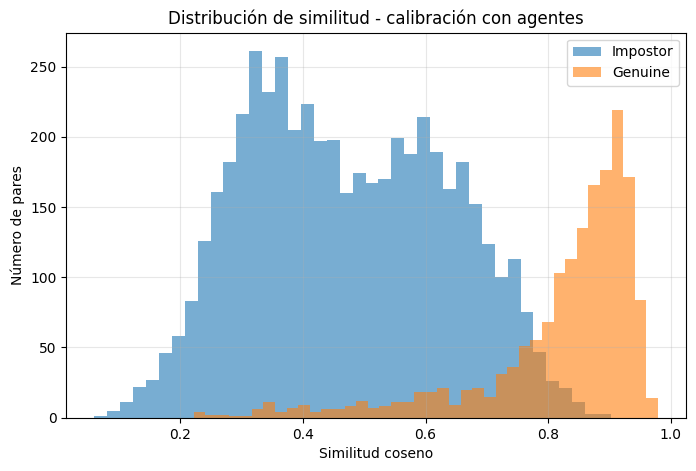

[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/figures/similarity_distribution_test_agents.png


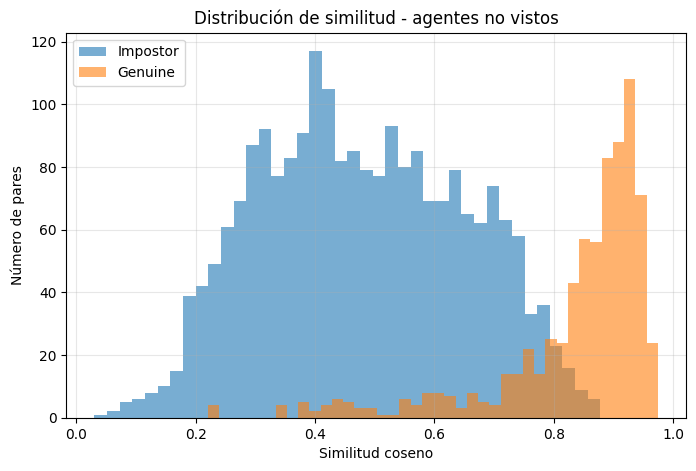

[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/figures/similarity_distribution_test_clients.png


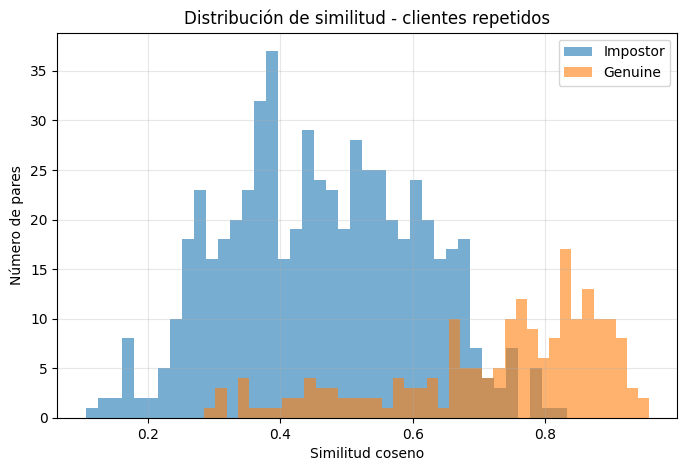

In [18]:
# ============================================================
# CELDA 17 - DISTRIBUCIONES DE SIMILITUD
# ============================================================

plot_similarity_distribution(
    df_pairs_calibration,
    "Distribución de similitud - calibración con agentes",
    FIGURES_DIR / "similarity_distribution_calibration_agents.png",
)

plot_similarity_distribution(
    df_pairs_agent_test,
    "Distribución de similitud - agentes no vistos",
    FIGURES_DIR / "similarity_distribution_test_agents.png",
)

plot_similarity_distribution(
    df_pairs_client_test,
    "Distribución de similitud - clientes repetidos",
    FIGURES_DIR / "similarity_distribution_test_clients.png",
)

[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/figures/roc_calibration_agents.png


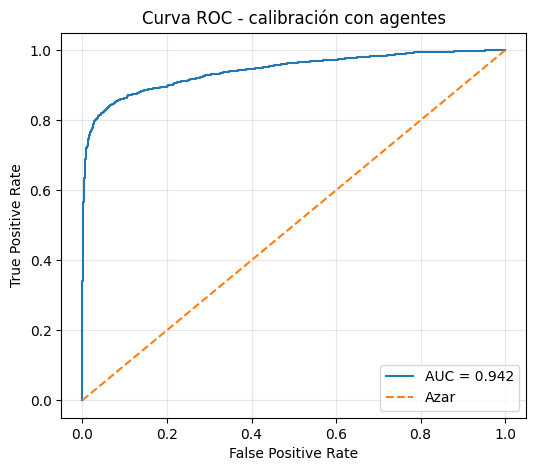

[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/figures/roc_test_agents.png


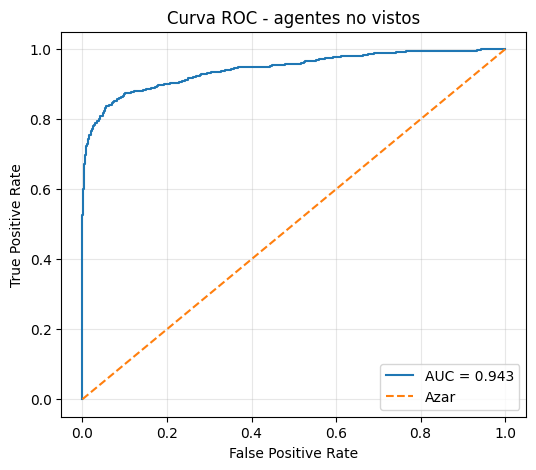

[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/figures/roc_test_clients.png


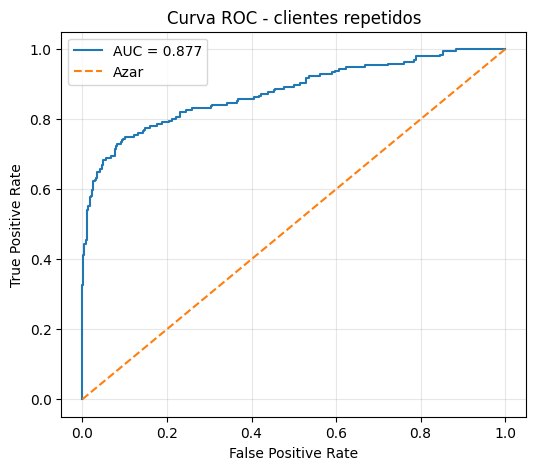

In [19]:
# ============================================================
# CELDA 18 - CURVAS ROC
# ============================================================

plot_roc_curve(
    df_pairs_calibration,
    "Curva ROC - calibración con agentes",
    FIGURES_DIR / "roc_calibration_agents.png",
)

plot_roc_curve(
    df_pairs_agent_test,
    "Curva ROC - agentes no vistos",
    FIGURES_DIR / "roc_test_agents.png",
)

plot_roc_curve(
    df_pairs_client_test,
    "Curva ROC - clientes repetidos",
    FIGURES_DIR / "roc_test_clients.png",
)

[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/figures/identity_repetition_by_role.png


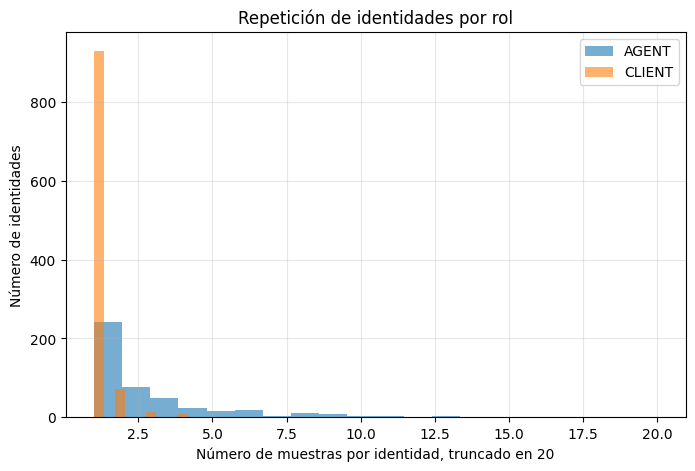

In [20]:
# ============================================================
# CELDA 19 - VISUALIZACIÓN DE REPETICIÓN DE IDENTIDADES
# ============================================================

plt.figure(figsize=(8, 5))
plot_df = identity_summary.copy()
plot_df["n_samples_capped"] = plot_df["n_samples"].clip(upper=20)
for role, group in plot_df.groupby("role_proxy"):
    plt.hist(group["n_samples_capped"], bins=20, alpha=0.6, label=role)
plt.title("Repetición de identidades por rol")
plt.xlabel("Número de muestras por identidad, truncado en 20")
plt.ylabel("Número de identidades")
plt.legend()
plt.grid(True, alpha=0.3)
IDENTITY_REPETITION_FIGURE = FIGURES_DIR / "identity_repetition_by_role.png"
plt.savefig(IDENTITY_REPETITION_FIGURE, dpi=160, bbox_inches="tight")
upload_file_to_gcs(IDENTITY_REPETITION_FIGURE)
plt.show()

## 8. Revisión cualitativa de pares

In [21]:
# ============================================================
# CELDA 20 - EJEMPLOS DE PARES MÁS Y MENOS SIMILARES
# ============================================================

def show_pair_examples(df_pairs, title, n=10):
    if df_pairs is None or df_pairs.empty:
        print("No hay pares para:", title)
        return
    print("=" * 80)
    print(title)
    print("=" * 80)
    cols = [
        "same_identity",
        "similarity",
        "person_id_a",
        "person_id_b",
        "role_a",
        "role_b",
        "audio_a",
        "audio_b",
        "sample_id_a",
        "sample_id_b",
    ]
    cols = [c for c in cols if c in df_pairs.columns]
    display(df_pairs.sort_values("similarity", ascending=False)[cols].head(n))
    display(df_pairs.sort_values("similarity", ascending=True)[cols].head(n))

show_pair_examples(df_pairs_agent_test, "Pares de agentes no vistos")
show_pair_examples(df_pairs_client_test, "Pares de clientes repetidos")

Pares de agentes no vistos


,same_identity,similarity,person_id_a,person_id_b,role_a,role_b,audio_a,audio_b,sample_id_a,sample_id_b
636,1,0.974254,dd201d76e2fe68ae,dd201d76e2fe68ae,AGENT,AGENT,raw_bajas_9156874494640006851_clean,raw_bajas_9156882996790016851_clean,S002071,S002072
384,1,0.973035,972e0786ad868a4b,972e0786ad868a4b,AGENT,AGENT,raw_bajas_9157331613790006851_clean,raw_bajas_9157348811950016851_clean,S001414,S001415
374,1,0.967901,972e0786ad868a4b,972e0786ad868a4b,AGENT,AGENT,raw_bajas_9156848029000006851_clean,raw_bajas_9157418711630016851_clean,S001411,S001417
373,1,0.965926,972e0786ad868a4b,972e0786ad868a4b,AGENT,AGENT,raw_bajas_9156848029000006851_clean,raw_bajas_9157393252240006851_clean,S001411,S001416
173,1,0.965500,471d774703e49d93,471d774703e49d93,AGENT,AGENT,raw_bajas_9157177088360016851_clean,raw_bajas_9157366951860006851_clean,S000673,S000675
530,1,0.965322,c1c38ff74077dc5d,c1c38ff74077dc5d,AGENT,AGENT,raw_bajas_9156397199460016851_clean,raw_bajas_9156448767380026851_clean,S001799,S001800
385,1,0.964771,972e0786ad868a4b,972e0786ad868a4b,AGENT,AGENT,raw_bajas_9157331613790006851_clean,raw_bajas_9157393252240006851_clean,S001414,S001416
386,1,0.964374,972e0786ad868a4b,972e0786ad868a4b,AGENT,AGENT,raw_bajas_9157331613790006851_clean,raw_bajas_9157418711630016851_clean,S001414,S001417
378,1,0.962890,972e0786ad868a4b,972e0786ad868a4b,AGENT,AGENT,raw_bajas_9157037964820006851_clean,raw_bajas_9157393252240006851_clean,S001412,S001416
502,1,0.962371,a95b360863ec5e0f,a95b360863ec5e0f,AGENT,AGENT,raw_bajas_9157132783720006851_clean,raw_bajas_9157270273410006851_clean,S001588,S001589


,same_identity,similarity,person_id_a,person_id_b,role_a,role_b,audio_a,audio_b,sample_id_a,sample_id_b
2511,0,0.030355,8b93bd2873abba79,a95b360863ec5e0f,AGENT,AGENT,raw_bajas_9157028012660016851_clean,raw_bajas_9157132783720006851_clean,S001324,S001588
1271,0,0.056015,972e0786ad868a4b,8774c1bf995efe03,AGENT,AGENT,raw_bajas_9157159528000026851_clean,raw_bajas_9156632507850016851_clean,S001413,S001270
2074,0,0.070175,7a3ac2bd7b47fb01,8b93bd2873abba79,AGENT,AGENT,raw_bajas_9157169077150006851_clean,raw_bajas_9157028012660016851_clean,S001143,S001324
1396,0,0.082022,6ae55dc4c3ae70c2,ee3b303a340552ab,AGENT,AGENT,raw_bajas_9157218056560006851_clean,raw_bajas_9156664071970016851_clean,S000983,S002183
2041,0,0.082099,26f667d98c589438,3b18a9f79bbf2ce9,AGENT,AGENT,raw_bajas_9157269887960006851_clean,raw_bajas_9156725216470006851_clean,S000402,S000564
1994,0,0.082742,ee3b303a340552ab,8774c1bf995efe03,AGENT,AGENT,raw_bajas_9157364999410006851_clean,raw_bajas_9156762393720006851_clean,S002189,S001271
1520,0,0.089165,ee3b303a340552ab,6ae55dc4c3ae70c2,AGENT,AGENT,raw_bajas_9156915269660006851_clean,raw_bajas_9157218056560006851_clean,S002186,S000983
2331,0,0.089365,ee3b303a340552ab,8774c1bf995efe03,AGENT,AGENT,raw_bajas_9156664071970016851_clean,raw_bajas_9156632507850016851_clean,S002183,S001270
911,0,0.102091,6ae55dc4c3ae70c2,ee3b303a340552ab,AGENT,AGENT,raw_bajas_9157218056560006851_clean,raw_bajas_9156674275230006851_clean,S000983,S002184
2136,0,0.102139,8b93bd2873abba79,c1c38ff74077dc5d,AGENT,AGENT,raw_bajas_9157028012660016851_clean,raw_bajas_9156796957200016851_clean,S001324,S001802


Pares de clientes repetidos


,same_identity,similarity,person_id_a,person_id_b,role_a,role_b,audio_a,audio_b,sample_id_a,sample_id_b
3,1,0.957005,0ba4d1a62404c7d3,0ba4d1a62404c7d3,CLIENT,CLIENT,raw_9156458226960006851_clean,raw_9156458509420006851_clean,S000095,S000096
46,1,0.940875,3a7e51937cc2544b,3a7e51937cc2544b,CLIENT,CLIENT,raw_9156270279010016851_clean,raw_9156457185310026851_clean,S000554,S000556
148,1,0.932750,9b3b058b04a46f6b,9b3b058b04a46f6b,CLIENT,CLIENT,raw_9154521617620006851_clean,raw_9155774206610016851_clean,S001451,S001453
172,1,0.930589,c9fbdfdded1719ea,c9fbdfdded1719ea,CLIENT,CLIENT,raw_bajas_9157391724440016851_clean,raw_bajas_9157393181540016851_clean,S001871,S001872
77,1,0.929079,6f3575d3ab9da486,6f3575d3ab9da486,CLIENT,CLIENT,raw_9154823963540016851_clean,raw_9154825192820016851_clean,S001046,S001047
34,1,0.919387,29ed7dbd4e787de9,29ed7dbd4e787de9,CLIENT,CLIENT,raw_9156190741830016851_clean,raw_9156190759670016851_clean,S000421,S000422
47,1,0.913548,3a7e51937cc2544b,3a7e51937cc2544b,CLIENT,CLIENT,raw_9156275777100006851_clean,raw_9156457185310026851_clean,S000555,S000556
135,1,0.912535,87ce1ac3d6ec0385,87ce1ac3d6ec0385,CLIENT,CLIENT,raw_bajas_9156119890800006851_clean,raw_bajas_9156120480010006851_clean,S001284,S001285
131,1,0.911430,87ac862422b770da,87ac862422b770da,CLIENT,CLIENT,raw_9154152155960016851_clean,raw_9154565956690016851_clean,S001280,S001282
76,1,0.910741,6e705320bb710bfe,6e705320bb710bfe,CLIENT,CLIENT,raw_9156330854170006851_clean,raw_9156337170240006851_clean,S001040,S001041


,same_identity,similarity,person_id_a,person_id_b,role_a,role_b,audio_a,audio_b,sample_id_a,sample_id_b
722,0,0.105743,70af57f2017b5af9,557938151ad865a0,CLIENT,CLIENT,raw_9155765842720006851_clean,raw_9155993306570006851_clean,S001066,S000808
502,0,0.132211,0d68d18d0d88bb86,2d148eb71130e13a,CLIENT,CLIENT,raw_bajas_9156034918850026851_clean,raw_9155309056180016851_clean,S000106,S000443
653,0,0.134401,73e95b4635bee260,c6527b83be5323fc,CLIENT,CLIENT,raw_9156304427750006851_clean,raw_9154281474720016851_clean,S001102,S001827
539,0,0.145658,978bcce7eb54bcd1,2d148eb71130e13a,CLIENT,CLIENT,raw_bajas_9156277009780006851_clean,raw_9156156834480016851_clean,S001420,S000444
423,0,0.157572,9b340c9787fc88fd,0d68d18d0d88bb86,CLIENT,CLIENT,raw_9156726743650026851_clean,raw_bajas_9156034918850026851_clean,S001450,S000106
686,0,0.161340,2d148eb71130e13a,27523bcf874e9065,CLIENT,CLIENT,raw_9155309056180016851_clean,raw_bajas_9156639673570006851_clean,S000443,S000409
685,0,0.165265,2f116bbab0ed59a5,0ba4d1a62404c7d3,CLIENT,CLIENT,raw_bajas_9157167199430056851_clean,raw_9156458226960006851_clean,S000456,S000095
486,0,0.169734,978bcce7eb54bcd1,9b3b058b04a46f6b,CLIENT,CLIENT,raw_bajas_9156277009780006851_clean,raw_9155774206610016851_clean,S001420,S001453
476,0,0.170379,978bcce7eb54bcd1,0bf279a865df9fb6,CLIENT,CLIENT,raw_bajas_9156277026630006851_clean,raw_9156802784450006851_clean,S001421,S000100
474,0,0.172877,9b3b058b04a46f6b,705f44f27ce3b4ff,CLIENT,CLIENT,raw_9155774206610016851_clean,raw_bajas_9157027999160006851_clean,S001453,S001063


## 9. Resumen final para memoria

In [22]:
# ============================================================
# CELDA 21 - RESUMEN FINAL EJECUTIVO
# ============================================================

summary_rows = []
summary_rows.append({"métrica": "Segmentos con embeddings", "valor": len(df_embeddings)})
summary_rows.append({"métrica": "Segmentos candidatos para huella", "valor": len(df_voiceprint_segments)})
summary_rows.append({"métrica": "Muestras audio-persona", "valor": len(df_samples)})
summary_rows.append({"métrica": "Identidades totales", "valor": identity_summary["person_id"].nunique()})
summary_rows.append({"métrica": "Identidades elegibles", "valor": int(identity_summary["eligible_verification"].sum())})
summary_rows.append({"métrica": "Agentes elegibles", "valor": len(eligible_agents)})
summary_rows.append({"métrica": "Clientes repetidos elegibles", "valor": len(eligible_clients)})
summary_rows.append({"métrica": "Umbral calibrado", "valor": round(float(VOICEPRINT_THRESHOLD), 4)})

for _, row in df_metrics.iterrows():
    summary_rows.append({"métrica": f"AUC - {row['dataset']}", "valor": None if pd.isna(row["auc"]) else round(float(row["auc"]), 4)})
    summary_rows.append({"métrica": f"EER - {row['dataset']}", "valor": None if pd.isna(row["eer"]) else round(float(row["eer"]), 4)})
    summary_rows.append({"métrica": f"F1 - {row['dataset']}", "valor": None if pd.isna(row["f1"]) else round(float(row["f1"]), 4)})

df_final_summary = pd.DataFrame(summary_rows)

FINAL_SUMMARY_CSV = VOICEPRINT_DIR / "voiceprint_final_summary_for_memory.csv"
save_dataframe_checkpoint(df_final_summary, FINAL_SUMMARY_CSV)

display(df_final_summary)
print("Resumen guardado en:", FINAL_SUMMARY_CSV)

print("\nInterpretación base:")
print(
    "La huella de voz se evaluó como verificación de hablante usando embeddings precomputados. "
    "El umbral se calibró con identidades de agentes y se aplicó a agentes no vistos y clientes repetidos, "
    "evitando que una misma identidad apareciera simultáneamente en calibración y prueba."
)

[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/voiceprint_final_summary_for_memory.csv
[CHECKPOINT] /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/voiceprint_final_summary_for_memory.csv | 17 filas


,métrica,valor
0,Segmentos con embeddings,43493.0000
1,Segmentos candidatos para huella,24487.0000
2,Muestras audio-persona,2322.0000
3,Identidades totales,1487.0000
4,Identidades elegibles,315.0000
5,Agentes elegibles,221.0000
6,Clientes repetidos elegibles,94.0000
7,Umbral calibrado,0.7294
8,AUC - calibration_agents,0.9424
9,EER - calibration_agents,0.1248


Resumen guardado en: /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/voiceprint_final_summary_for_memory.csv

Interpretación base:
La huella de voz se evaluó como verificación de hablante usando embeddings precomputados. El umbral se calibró con identidades de agentes y se aplicó a agentes no vistos y clientes repetidos, evitando que una misma identidad apareciera simultáneamente en calibración y prueba.


## 10. Nota metodológica

Este notebook no calcula DER ni identifica nombres reales. La evaluación se basa en identidades proxy anonimizadas (`agent_hash` y `customer_hash`) y mide si la similitud entre embeddings es mayor para pares de la misma identidad que para pares de identidades distintas.

La evaluación de clientes debe interpretarse con cautela si el número de clientes repetidos es bajo. Aun así, permite probar el caso de uso más relevante: detectar recurrencia de un cliente a partir de su voz.

# 10. Extensión: enrollment e identificación open-set

Esta sección no sustituye la verificación por pares anterior. Construye perfiles con unas llamadas y consulta con llamadas distintas de la misma identidad. Algunas identidades completas se reservan como `UNKNOWN` para medir el rechazo de hablantes no registrados.


In [23]:
# ============================================================
# CELDA 22 - PREPARAR MUESTRAS PARA OPEN-SET
# ============================================================

# Copia independiente: no modifica los outputs anteriores.
df_samples_open_set = df_samples.copy()
df_samples_open_set['source_identity_id'] = (
    df_samples_open_set['person_id'].astype(str)
)

identity_summary_open_set = (
    df_samples_open_set
    .groupby(['role_proxy', 'person_id', 'source_identity_id'], dropna=False)
    .agg(
        n_samples=('sample_id', 'size'),
        n_calls=('audio_key', 'nunique'),
        total_segments=('n_segments', 'sum'),
        total_duration_sec=('sample_duration_sec', 'sum'),
        mean_sample_duration_sec=('sample_duration_sec', 'mean'),
    )
    .reset_index()
)

identity_summary_open_set['eligible_profile'] = (
    identity_summary_open_set['n_samples'].ge(
        OPEN_SET_MIN_SAMPLES_PER_IDENTITY
    )
    & identity_summary_open_set['total_duration_sec'].ge(
        OPEN_SET_MIN_TOTAL_SECONDS_PER_IDENTITY
    )
)

OPEN_SET_IDENTITY_SUMMARY_PATH = (
    VOICEPRINT_DIR / 'voiceprint_identity_summary_open_set.csv'
)
save_dataframe_checkpoint(
    identity_summary_open_set,
    OPEN_SET_IDENTITY_SUMMARY_PATH,
)

display(
    identity_summary_open_set.groupby('role_proxy')
    .agg(
        identities=('person_id', 'nunique'),
        eligible=('eligible_profile', 'sum'),
        median_calls=('n_calls', 'median'),
        max_calls=('n_calls', 'max'),
    )
    .reset_index()
)


[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/voiceprint_identity_summary_open_set.csv
[CHECKPOINT] /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/voiceprint_identity_summary_open_set.csv | 1,487 filas


,role_proxy,identities,eligible,median_calls,max_calls
0,AGENT,462,143,1.0,24
1,CLIENT,1025,22,1.0,8


## 10.1 División enrollment/query y reserva de identidades unknown


In [24]:
# ============================================================
# CELDA 9 - FUNCIONES DE SPLIT
# ============================================================

def deterministic_identity_partition(identity_ids, random_state=RANDOM_SEED):
    ids = sorted({str(x) for x in identity_ids})
    rng = np.random.default_rng(random_state)
    ids = list(rng.permutation(ids))
    n_ids = len(ids)

    if n_ids < MIN_IDENTITIES_FOR_FORMAL_OPEN_SET:
        raise ValueError(
            f"Solo hay {n_ids} agentes elegibles. Se necesitan al menos "
            f"{MIN_IDENTITIES_FOR_FORMAL_OPEN_SET} para separar calibración, "
            "test conocido y test unknown."
        )

    n_unknown = max(1, int(round(n_ids * UNKNOWN_IDENTITY_FRACTION)))
    n_unknown = min(n_unknown, n_ids - 4)
    unknown_ids = ids[:n_unknown]
    known_pool = ids[n_unknown:]

    n_test_known = max(2, int(round(len(known_pool) * TEST_KNOWN_IDENTITY_FRACTION)))
    n_test_known = min(n_test_known, len(known_pool) - 2)

    return {
        "calibration_known": sorted(known_pool[n_test_known:]),
        "test_known": sorted(known_pool[:n_test_known]),
        "test_unknown": sorted(unknown_ids),
    }


def split_identity_calls(samples, identity_ids, group_label, random_state):
    rng = np.random.default_rng(random_state)
    rows = []

    subset = samples[
        samples["person_id"].astype(str).isin(set(map(str, identity_ids)))
    ].copy()

    for person_id, group in subset.groupby("person_id", sort=True):
        group = group.sort_values(["audio_key", "sample_id"]).copy()
        indices = list(rng.permutation(group.index.to_list()))
        n_samples = len(indices)

        n_query = max(MIN_QUERY_SAMPLES, int(round(n_samples * QUERY_FRACTION)))
        n_query = min(n_query, n_samples - MIN_ENROLLMENT_SAMPLES)

        if n_query < MIN_QUERY_SAMPLES:
            raise ValueError(
                f"{person_id} no permite separar enrollment/query: "
                f"{n_samples} muestras."
            )

        query_indices = set(indices[:n_query])

        for index in indices:
            row = group.loc[index]
            rows.append({
                "sample_id": row["sample_id"],
                "person_id": str(person_id),
                "source_identity_id": row["source_identity_id"],
                "role_proxy": row["role_proxy"],
                "audio_key": row["audio_key"],
                "identity_group": group_label,
                "sample_split": "query" if index in query_indices else "enrollment",
            })

    return pd.DataFrame(rows)


def build_open_set_split(samples, agent_identity_ids):
    partition = deterministic_identity_partition(agent_identity_ids)

    calibration = split_identity_calls(
        samples,
        partition["calibration_known"],
        "calibration_known",
        RANDOM_SEED + 11,
    )
    test_known = split_identity_calls(
        samples,
        partition["test_known"],
        "test_known",
        RANDOM_SEED + 22,
    )

    unknown = samples[
        samples["person_id"].astype(str).isin(set(partition["test_unknown"]))
    ][[
        "sample_id", "person_id", "source_identity_id",
        "role_proxy", "audio_key",
    ]].copy()
    unknown["identity_group"] = "test_unknown"
    unknown["sample_split"] = "query"

    split = pd.concat([calibration, test_known, unknown], ignore_index=True)

    if not split[
        split["identity_group"].eq("test_unknown")
        & split["sample_split"].eq("enrollment")
    ].empty:
        raise AssertionError("Una identidad unknown apareció en enrollment.")

    return split, partition


In [25]:
# ============================================================
# CELDA 10 - CREAR O CARGAR SPLIT
# ============================================================

SPLIT_CHECKPOINT = CHECKPOINT_DIR / "04_voiceprint_open_set_split.csv"
PARTITION_CHECKPOINT = CHECKPOINT_DIR / "04_voiceprint_identity_partition.json"

df_open_set_split = load_dataframe_checkpoint(SPLIT_CHECKPOINT)

if (
    df_open_set_split is None
    or FORCE_REBUILD
    or not ensure_local_checkpoint(PARTITION_CHECKPOINT)
):
    eligible_agents = (
        identity_summary_open_set[
            identity_summary_open_set["role_proxy"].eq("AGENT")
            & identity_summary_open_set["eligible_profile"].astype(bool)
        ]["person_id"]
        .dropna()
        .astype(str)
        .tolist()
    )

    df_open_set_split, identity_partition = build_open_set_split(
        df_samples_open_set,
        eligible_agents,
    )

    save_dataframe_checkpoint(df_open_set_split, SPLIT_CHECKPOINT)
    save_json_checkpoint(identity_partition, PARTITION_CHECKPOINT)
else:
    with open(PARTITION_CHECKPOINT, "r", encoding="utf-8") as file:
        identity_partition = json.load(file)

print({key: len(value) for key, value in identity_partition.items()})

display(
    df_open_set_split.groupby(["identity_group", "sample_split"])
    .agg(
        identities=("person_id", "nunique"),
        samples=("sample_id", "size"),
        calls=("audio_key", "nunique"),
    )
    .reset_index()
)


[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/checkpoints/04_voiceprint_open_set_split.csv
[CHECKPOINT] /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/checkpoints/04_voiceprint_open_set_split.csv | 769 filas
[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/checkpoints/04_voiceprint_identity_partition.json
[CHECKPOINT] /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/checkpoints/04_voiceprint_identity_partition.json
{'calibration_known': 80, 'test_known': 34, 'test_unknown': 29}


,identity_group,sample_split,identities,samples,calls
0,calibration_known,enrollment,80,288,288
1,calibration_known,query,80,133,133
2,test_known,enrollment,34,133,133
3,test_known,query,34,61,61
4,test_unknown,query,29,154,154


## 10.2 Construcción de perfiles de enrollment


In [26]:
# ============================================================
# CELDA 11 - FUNCIONES DE PERFILES
# ============================================================

def calculate_within_profile_similarity(sample_embeddings, centroid):
    similarities = cosine_similarity_matrix(
        sample_embeddings,
        centroid.reshape(1, -1),
    ).reshape(-1)

    return {
        "within_similarity_mean": float(np.mean(similarities)),
        "within_similarity_std": float(np.std(similarities)),
        "within_similarity_min": float(np.min(similarities)),
        "within_similarity_max": float(np.max(similarities)),
    }


def build_speaker_profiles(enrollment_samples, embedding_columns, profile_set_name):
    rows = []

    for person_id, group in enrollment_samples.groupby("person_id", sort=True):
        matrix = l2_normalize_matrix(
            group[embedding_columns].to_numpy(dtype=np.float32)
        )
        centroid = l2_normalize_matrix(matrix.mean(axis=0).reshape(1, -1)).reshape(-1)
        consistency = calculate_within_profile_similarity(matrix, centroid)

        row = {
            "profile_id": str(person_id),
            "source_identity_id": group["source_identity_id"].iloc[0],
            "role_proxy": group["role_proxy"].iloc[0],
            "profile_set": profile_set_name,
            "n_enrollment_samples": int(len(group)),
            "n_enrollment_calls": int(group["audio_key"].nunique()),
            "n_enrollment_segments": int(group["n_segments"].fillna(0).sum()),
            "total_enrollment_duration_sec": float(
                group["sample_duration_sec"].fillna(0).sum()
            ),
            "mean_sample_duration_sec": float(
                group["sample_duration_sec"].fillna(0).mean()
            ),
            "mean_overlap_ratio": (
                float(group["mean_overlap_ratio"].mean())
                if "mean_overlap_ratio" in group.columns else np.nan
            ),
            "mean_rms_dbfs": (
                float(group["mean_rms_dbfs"].mean())
                if "mean_rms_dbfs" in group.columns else np.nan
            ),
            "embedding_dim": len(embedding_columns),
            "embedding_model": EMBEDDING_MODEL_LABEL,
            "notebook_version": NOTEBOOK_VERSION,
            **consistency,
        }
        row.update({
            column: float(value)
            for column, value in zip(embedding_columns, centroid)
        })
        rows.append(row)

    profiles = pd.DataFrame(rows)
    if not profiles.empty:
        profiles[embedding_columns] = l2_normalize_matrix(
            profiles[embedding_columns].to_numpy(dtype=np.float32)
        )
    return profiles


def get_samples_for_split(samples, split, identity_group, sample_split):
    ids = split[
        split["identity_group"].eq(identity_group)
        & split["sample_split"].eq(sample_split)
    ]["sample_id"]

    return samples[
        samples["sample_id"].isin(set(ids))
    ].copy().reset_index(drop=True)


In [27]:
# ============================================================
# CELDA 12 - PERFILES DE CALIBRACIÓN Y TEST
# ============================================================

CALIBRATION_PROFILES_CHECKPOINT = CHECKPOINT_DIR / "05_agent_profiles_calibration.csv"
TEST_PROFILES_CHECKPOINT = CHECKPOINT_DIR / "05_agent_profiles_test.csv"

calibration_profiles = load_dataframe_checkpoint(CALIBRATION_PROFILES_CHECKPOINT)
test_profiles = load_dataframe_checkpoint(TEST_PROFILES_CHECKPOINT)

if calibration_profiles is None:
    calibration_enrollment = get_samples_for_split(
        df_samples_open_set, df_open_set_split, "calibration_known", "enrollment"
    )
    calibration_profiles = build_speaker_profiles(
        calibration_enrollment,
        emb_cols,
        "calibration",
    )
    save_dataframe_checkpoint(
        calibration_profiles,
        CALIBRATION_PROFILES_CHECKPOINT,
    )

if test_profiles is None:
    test_enrollment = get_samples_for_split(
        df_samples_open_set, df_open_set_split, "test_known", "enrollment"
    )
    test_profiles = build_speaker_profiles(
        test_enrollment,
        emb_cols,
        "test",
    )
    save_dataframe_checkpoint(test_profiles, TEST_PROFILES_CHECKPOINT)

print("Perfiles calibración:", len(calibration_profiles))
print("Perfiles test:", len(test_profiles))

display(
    calibration_profiles[[
        "profile_id",
        "n_enrollment_calls",
        "n_enrollment_segments",
        "total_enrollment_duration_sec",
        "within_similarity_mean",
        "within_similarity_min",
    ]].head()
)


[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/checkpoints/05_agent_profiles_calibration.csv
[CHECKPOINT] /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/checkpoints/05_agent_profiles_calibration.csv | 80 filas
[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/checkpoints/05_agent_profiles_test.csv
[CHECKPOINT] /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/checkpoints/05_agent_profiles_test.csv | 34 filas
Perfiles calibración: 80
Perfiles test: 34


,profile_id,n_enrollment_calls,n_enrollment_segments,total_enrollment_duration_sec,within_similarity_mean,within_similarity_min
0,0426c69ad8b47dfe,2,7,33.429375,0.830094,0.830094
1,10c97ff2ae63bfac,3,28,153.900000,0.975425,0.969685
2,12de5815bbe90aa8,3,34,174.791250,0.980393,0.977717
3,138c6eb33dfd2ffe,3,20,73.558125,0.898177,0.852544
4,13e5973e81974091,6,61,344.385000,0.953869,0.900520


## 10.3 Calibración e identificación open-set


In [28]:
# ============================================================
# CELDA 13 - FUNCIONES DE IDENTIFICACIÓN Y UMBRAL
# ============================================================

def score_queries_against_profiles(
    query_samples,
    profiles,
    embedding_columns,
    query_group,
):
    if query_samples.empty:
        return pd.DataFrame(), pd.DataFrame()
    if profiles.empty:
        raise ValueError(f"No hay perfiles para consultar {query_group}.")

    query_matrix = query_samples[embedding_columns].to_numpy(dtype=np.float32)
    profile_matrix = profiles[embedding_columns].to_numpy(dtype=np.float32)
    similarities = cosine_similarity_matrix(query_matrix, profile_matrix)
    profile_ids = profiles["profile_id"].astype(str).to_numpy()
    profile_source_ids = profiles["source_identity_id"].astype(str).to_numpy()
    profile_id_set = set(profile_ids)

    score_rows = []
    prediction_rows = []

    for qpos, (_, query) in enumerate(query_samples.reset_index(drop=True).iterrows()):
        query_scores = similarities[qpos]
        order = np.argsort(-query_scores)
        best_idx = int(order[0])
        second_idx = int(order[1]) if len(order) > 1 else None

        best_profile_id = profile_ids[best_idx]
        best_source_identity_id = profile_source_ids[best_idx]
        best_score = float(query_scores[best_idx])

        if second_idx is None:
            second_profile_id = None
            second_source_identity_id = None
            second_score = np.nan
            margin = np.nan
        else:
            second_profile_id = profile_ids[second_idx]
            second_source_identity_id = profile_source_ids[second_idx]
            second_score = float(query_scores[second_idx])
            margin = best_score - second_score

        true_person_id = str(query["person_id"])
        true_is_enrolled = true_person_id in profile_id_set

        prediction_rows.append({
            "query_group": query_group,
            "sample_id": query["sample_id"],
            "audio_key": query["audio_key"],
            "true_person_id": true_person_id,
            "true_source_identity_id": query.get("source_identity_id", pd.NA),
            "true_is_enrolled": bool(true_is_enrolled),
            "best_profile_id": best_profile_id,
            "best_source_identity_id": best_source_identity_id,
            "best_similarity": best_score,
            "second_profile_id": second_profile_id,
            "second_source_identity_id": second_source_identity_id,
            "second_similarity": second_score,
            "top1_top2_margin": margin,
            "top1_correct_before_threshold": (
                bool(true_is_enrolled)
                and best_profile_id == true_person_id
            ),
        })

        for ppos, profile_id in enumerate(profile_ids):
            score_rows.append({
                "query_group": query_group,
                "sample_id": query["sample_id"],
                "audio_key": query["audio_key"],
                "true_person_id": true_person_id,
                "true_is_enrolled": bool(true_is_enrolled),
                "candidate_profile_id": str(profile_id),
                "same_identity": int(
                    true_is_enrolled and str(profile_id) == true_person_id
                ),
                "similarity": float(query_scores[ppos]),
            })

    return pd.DataFrame(score_rows), pd.DataFrame(prediction_rows)


def choose_verification_threshold(score_table, strategy="eer"):
    if score_table.empty:
        raise ValueError("No hay scores para calibrar el umbral.")

    y_true = score_table["same_identity"].astype(int).to_numpy()
    scores = score_table["similarity"].astype(float).to_numpy()

    if len(np.unique(y_true)) < 2:
        raise ValueError("La calibración necesita scores genuine e impostor.")

    fpr, tpr, thresholds = roc_curve(y_true, scores)
    fnr = 1 - tpr

    eer_idx = int(np.nanargmin(np.abs(fpr - fnr)))
    youden_idx = int(np.nanargmax(tpr - fpr))
    selected_idx = eer_idx if strategy.lower() == "eer" else youden_idx

    return {
        "strategy": strategy.lower(),
        "acceptance_threshold": float(thresholds[selected_idx]),
        "eer": float((fpr[eer_idx] + fnr[eer_idx]) / 2),
        "eer_threshold": float(thresholds[eer_idx]),
        "youden_threshold": float(thresholds[youden_idx]),
        "calibration_auc": float(roc_auc_score(y_true, scores)),
        "n_scores": int(len(score_table)),
        "n_genuine_scores": int((y_true == 1).sum()),
        "n_impostor_scores": int((y_true == 0).sum()),
    }


def apply_open_set_decision(predictions, threshold):
    output = predictions.copy()
    output["decision"] = np.where(
        output["best_similarity"].ge(threshold),
        "KNOWN",
        "UNKNOWN",
    )
    output["predicted_person_id"] = np.where(
        output["decision"].eq("KNOWN"),
        output["best_profile_id"],
        pd.NA,
    )
    output["predicted_source_identity_id"] = np.where(
        output["decision"].eq("KNOWN"),
        output["best_source_identity_id"],
        pd.NA,
    )
    output["provisional_unknown_id"] = np.where(
        output["decision"].eq("UNKNOWN"),
        "UNKNOWN::" + output["sample_id"].astype(str),
        pd.NA,
    )
    output["identification_correct"] = False
    known_truth = output["true_is_enrolled"].fillna(False).astype(bool)

    predicted_ids = (
        output.loc[known_truth, "predicted_person_id"]
        .astype("string")
    )
    true_ids = (
        output.loc[known_truth, "true_person_id"]
        .astype("string")
    )

    id_match = (
        predicted_ids.notna()
        & true_ids.notna()
        & predicted_ids.eq(true_ids).fillna(False)
    )

    output.loc[known_truth, "identification_correct"] = (
        output.loc[known_truth, "decision"].eq("KNOWN").to_numpy()
        & id_match.to_numpy(dtype=bool)
    )

    output.loc[~known_truth, "identification_correct"] = (
        output.loc[~known_truth, "decision"].eq("UNKNOWN")
    )

    output["identification_correct"] = (
        output["identification_correct"].fillna(False).astype(bool)
    )
    return output


In [29]:
# ============================================================
# CELDA 14 - CALIBRAR UMBRAL CON QUERIES NO VISTAS
# ============================================================

CALIBRATION_SCORES_CHECKPOINT = (
    CHECKPOINT_DIR / "06_calibration_query_profile_scores.csv"
)
CALIBRATION_PREDICTIONS_CHECKPOINT = (
    CHECKPOINT_DIR / "06_calibration_top1_predictions.csv"
)
THRESHOLD_CHECKPOINT = VOICEPRINT_DIR / "voiceprint_thresholds.json"

calibration_scores = load_dataframe_checkpoint(CALIBRATION_SCORES_CHECKPOINT)
calibration_predictions = load_dataframe_checkpoint(
    CALIBRATION_PREDICTIONS_CHECKPOINT
)

if calibration_scores is None or calibration_predictions is None:
    calibration_queries = get_samples_for_split(
        df_samples_open_set,
        df_open_set_split,
        "calibration_known",
        "query",
    )

    calibration_scores, calibration_predictions = (
        score_queries_against_profiles(
            calibration_queries,
            calibration_profiles,
            emb_cols,
            "calibration_known",
        )
    )

    save_dataframe_checkpoint(
        calibration_scores,
        CALIBRATION_SCORES_CHECKPOINT,
    )
    save_dataframe_checkpoint(
        calibration_predictions,
        CALIBRATION_PREDICTIONS_CHECKPOINT,
    )

if FORCE_REBUILD or not ensure_local_checkpoint(THRESHOLD_CHECKPOINT):
    open_set_threshold_info = choose_verification_threshold(
        calibration_scores,
        OPEN_SET_THRESHOLD_STRATEGY,
    )
    open_set_threshold_info.update({
        "created_at_utc": utc_now_iso(),
        "embedding_model": EMBEDDING_MODEL_LABEL,
        "embedding_dim": len(emb_cols),
        "notebook_version": NOTEBOOK_VERSION,
        "calibration_identity_count": int(
            calibration_profiles["profile_id"].nunique()
        ),
    })
    save_json_checkpoint(open_set_threshold_info, THRESHOLD_CHECKPOINT)
else:
    with open(THRESHOLD_CHECKPOINT, "r", encoding="utf-8") as file:
        open_set_threshold_info = json.load(file)

OPEN_SET_THRESHOLD = float(open_set_threshold_info["acceptance_threshold"])

print(
    "Umbral:",
    round(OPEN_SET_THRESHOLD, 4),
    "| estrategia:",
    open_set_threshold_info["strategy"],
    "| EER:",
    round(float(open_set_threshold_info["eer"]), 4),
    "| AUC:",
    round(float(open_set_threshold_info["calibration_auc"]), 4),
)


[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/checkpoints/06_calibration_query_profile_scores.csv
[CHECKPOINT] /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/checkpoints/06_calibration_query_profile_scores.csv | 10,640 filas
[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/checkpoints/06_calibration_top1_predictions.csv
[CHECKPOINT] /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/checkpoints/06_calibration_top1_predictions.csv | 133 filas
[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/voiceprint_thresholds.json
[CHECKPOINT] /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/voiceprint_thresholds.json
Umbral: 0.7529 | estrategia: eer | EER: 0.0831 | AUC: 0.9725


In [30]:
# ============================================================
# CELDA 15 - TEST KNOWN Y TEST UNKNOWN
# ============================================================

TEST_KNOWN_SCORES_CHECKPOINT = (
    CHECKPOINT_DIR / "07_test_known_query_profile_scores.csv"
)
TEST_KNOWN_PREDICTIONS_CHECKPOINT = (
    CHECKPOINT_DIR / "07_test_known_top1_predictions.csv"
)
TEST_UNKNOWN_SCORES_CHECKPOINT = (
    CHECKPOINT_DIR / "07_test_unknown_query_profile_scores.csv"
)
TEST_UNKNOWN_PREDICTIONS_CHECKPOINT = (
    CHECKPOINT_DIR / "07_test_unknown_top1_predictions.csv"
)

test_known_scores = load_dataframe_checkpoint(TEST_KNOWN_SCORES_CHECKPOINT)
test_known_predictions = load_dataframe_checkpoint(
    TEST_KNOWN_PREDICTIONS_CHECKPOINT
)
test_unknown_scores = load_dataframe_checkpoint(
    TEST_UNKNOWN_SCORES_CHECKPOINT
)
test_unknown_predictions = load_dataframe_checkpoint(
    TEST_UNKNOWN_PREDICTIONS_CHECKPOINT
)

if test_known_scores is None or test_known_predictions is None:
    test_known_queries = get_samples_for_split(
        df_samples_open_set,
        df_open_set_split,
        "test_known",
        "query",
    )
    test_known_scores, test_known_predictions = (
        score_queries_against_profiles(
            test_known_queries,
            test_profiles,
            emb_cols,
            "test_known",
        )
    )
    save_dataframe_checkpoint(
        test_known_scores,
        TEST_KNOWN_SCORES_CHECKPOINT,
    )
    save_dataframe_checkpoint(
        test_known_predictions,
        TEST_KNOWN_PREDICTIONS_CHECKPOINT,
    )

if test_unknown_scores is None or test_unknown_predictions is None:
    test_unknown_queries = get_samples_for_split(
        df_samples_open_set,
        df_open_set_split,
        "test_unknown",
        "query",
    )
    test_unknown_scores, test_unknown_predictions = (
        score_queries_against_profiles(
            test_unknown_queries,
            test_profiles,
            emb_cols,
            "test_unknown",
        )
    )
    save_dataframe_checkpoint(
        test_unknown_scores,
        TEST_UNKNOWN_SCORES_CHECKPOINT,
    )
    save_dataframe_checkpoint(
        test_unknown_predictions,
        TEST_UNKNOWN_PREDICTIONS_CHECKPOINT,
    )

df_open_set_predictions = pd.concat(
    [
        apply_open_set_decision(
            test_known_predictions,
            OPEN_SET_THRESHOLD,
        ),
        apply_open_set_decision(
            test_unknown_predictions,
            OPEN_SET_THRESHOLD,
        ),
    ],
    ignore_index=True,
)

OPEN_SET_PREDICTIONS_PATH = (
    VOICEPRINT_DIR / "open_set_identification_predictions.csv"
)
save_dataframe_checkpoint(
    df_open_set_predictions,
    OPEN_SET_PREDICTIONS_PATH,
)

display(
    df_open_set_predictions[[
        "query_group",
        "audio_key",
        "true_source_identity_id",
        "best_profile_id",
        "best_source_identity_id",
        "best_similarity",
        "top1_top2_margin",
        "decision",
        "identification_correct",
    ]].head(20)
)


[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/checkpoints/07_test_known_query_profile_scores.csv
[CHECKPOINT] /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/checkpoints/07_test_known_query_profile_scores.csv | 2,074 filas
[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/checkpoints/07_test_known_top1_predictions.csv
[CHECKPOINT] /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/checkpoints/07_test_known_top1_predictions.csv | 61 filas
[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/checkpoints/07_test_unknown_query_profile_scores.csv
[CHECKPOINT] /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/checkpoints/07_test_unknown_query_profile_scores.csv | 5,236 filas
[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/checkpoints/07_test_unknown_top1_predictions.csv
[CHECKPOINT] /home/jupyter/TFM_Procesad

,query_group,audio_key,true_source_identity_id,best_profile_id,best_source_identity_id,best_similarity,top1_top2_margin,decision,identification_correct
0,test_known,raw_bajas_9156848840280006851_clean,105c9f19ab40d4e6,105c9f19ab40d4e6,105c9f19ab40d4e6,0.940742,0.171502,KNOWN,True
1,test_known,raw_bajas_9157237809470006851_clean,105c9f19ab40d4e6,105c9f19ab40d4e6,105c9f19ab40d4e6,0.947920,0.101997,KNOWN,True
2,test_known,raw_bajas_9156034064680006851_clean,110cf1c58104bf3b,110cf1c58104bf3b,110cf1c58104bf3b,0.909246,0.223986,KNOWN,True
3,test_known,raw_bajas_9156433600170006851_clean,110cf1c58104bf3b,110cf1c58104bf3b,110cf1c58104bf3b,0.948642,0.277001,KNOWN,True
4,test_known,raw_bajas_9157088440820006851_clean,110cf1c58104bf3b,110cf1c58104bf3b,110cf1c58104bf3b,0.843362,0.197937,KNOWN,True
5,test_known,raw_bajas_9156984223330006851_clean,1118726aa9049223,1118726aa9049223,1118726aa9049223,0.947779,0.267066,KNOWN,True
6,test_known,raw_bajas_9156985208300006851_clean,1118726aa9049223,1118726aa9049223,1118726aa9049223,0.949706,0.299201,KNOWN,True
7,test_known,raw_bajas_9157391375210006851_clean,1118726aa9049223,1118726aa9049223,1118726aa9049223,0.970741,0.286201,KNOWN,True
8,test_known,raw_bajas_9156915153480006851_clean,14b53727a1388245,14b53727a1388245,14b53727a1388245,0.899530,0.121933,KNOWN,True
9,test_known,raw_bajas_9156545484670006851_clean,1ca59bf72dd4bbbd,1ca59bf72dd4bbbd,1ca59bf72dd4bbbd,0.937205,0.143028,KNOWN,True


In [31]:
# ============================================================
# CELDA 16 - MÉTRICAS
# ============================================================

def safe_ratio(numerator, denominator):
    return float(numerator / denominator) if denominator else np.nan


def evaluate_score_table(score_table, label, threshold):
    if score_table.empty:
        return {"dataset": label, "n_scores": 0}

    y_true = score_table["same_identity"].astype(int).to_numpy()
    scores = score_table["similarity"].astype(float).to_numpy()
    y_pred = scores >= threshold

    if len(np.unique(y_true)) == 2:
        auc = float(roc_auc_score(y_true, scores))
        fpr, tpr, _ = roc_curve(y_true, scores)
        fnr = 1 - tpr
        eer_idx = int(np.nanargmin(np.abs(fpr - fnr)))
        eer = float((fpr[eer_idx] + fnr[eer_idx]) / 2)
    else:
        auc = np.nan
        eer = np.nan

    return {
        "dataset": label,
        "n_scores": int(len(score_table)),
        "n_genuine": int((y_true == 1).sum()),
        "n_impostor": int((y_true == 0).sum()),
        "threshold": float(threshold),
        "auc": auc,
        "eer": eer,
        "verification_accuracy": float(accuracy_score(y_true, y_pred)),
        "verification_precision": float(
            precision_score(y_true, y_pred, zero_division=0)
        ),
        "verification_recall": float(
            recall_score(y_true, y_pred, zero_division=0)
        ),
        "verification_f1": float(
            f1_score(y_true, y_pred, zero_division=0)
        ),
    }


known_rows = df_open_set_predictions[
    df_open_set_predictions["true_is_enrolled"].astype(bool)
].copy()

unknown_rows = df_open_set_predictions[
    ~df_open_set_predictions["true_is_enrolled"].astype(bool)
].copy()

identification_metrics = {
    "created_at_utc": utc_now_iso(),
    "threshold": OPEN_SET_THRESHOLD,
    "n_known_queries": int(len(known_rows)),
    "n_unknown_queries": int(len(unknown_rows)),
    "known_top1_accuracy_before_rejection": safe_ratio(
        int(known_rows["top1_correct_before_threshold"].sum()),
        len(known_rows),
    ),
    "known_identification_rate": safe_ratio(
        int(known_rows["identification_correct"].sum()),
        len(known_rows),
    ),
    "known_false_rejection_rate": safe_ratio(
        int(known_rows["decision"].eq("UNKNOWN").sum()),
        len(known_rows),
    ),
    "unknown_rejection_rate": safe_ratio(
        int(unknown_rows["decision"].eq("UNKNOWN").sum()),
        len(unknown_rows),
    ),
    "unknown_false_acceptance_rate": safe_ratio(
        int(unknown_rows["decision"].eq("KNOWN").sum()),
        len(unknown_rows),
    ),
    "overall_open_set_accuracy": safe_ratio(
        int(df_open_set_predictions["identification_correct"].sum()),
        len(df_open_set_predictions),
    ),
}

verification_metrics = pd.DataFrame([
    evaluate_score_table(
        calibration_scores,
        "calibration_known",
        OPEN_SET_THRESHOLD,
    ),
    evaluate_score_table(
        test_known_scores,
        "test_known",
        OPEN_SET_THRESHOLD,
    ),
])

IDENTIFICATION_METRICS_PATH = (
    VOICEPRINT_DIR / "open_set_identification_metrics.json"
)
VERIFICATION_METRICS_PATH = (
    VOICEPRINT_DIR / "voiceprint_verification_metrics.csv"
)

save_json_checkpoint(
    identification_metrics,
    IDENTIFICATION_METRICS_PATH,
)
save_dataframe_checkpoint(
    verification_metrics,
    VERIFICATION_METRICS_PATH,
)

display(verification_metrics)
display(pd.DataFrame([identification_metrics]))


[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/open_set_identification_metrics.json
[CHECKPOINT] /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/open_set_identification_metrics.json
[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/voiceprint_verification_metrics.csv
[CHECKPOINT] /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/voiceprint_verification_metrics.csv | 2 filas


,dataset,n_scores,n_genuine,n_impostor,threshold,auc,eer,verification_accuracy,verification_precision,verification_recall,verification_f1
0,calibration_known,10640,133,10507,0.752867,0.972527,0.083135,0.916447,0.122000,0.917293,0.215357
1,test_known,2074,61,2013,0.752867,0.953955,0.097367,0.937319,0.302857,0.868852,0.449153


,created_at_utc,threshold,n_known_queries,n_unknown_queries,known_top1_accuracy_before_rejection,known_identification_rate,known_false_rejection_rate,unknown_rejection_rate,unknown_false_acceptance_rate,overall_open_set_accuracy
0,2026-07-13T16:32:20.162293+00:00,0.752867,61,154,0.885246,0.836066,0.114754,0.5,0.5,0.595349


In [32]:
# ============================================================
# CELDA 17 - MATRIZ DE DECISIÓN KNOWN / UNKNOWN
# ============================================================

decision_true = np.where(
    df_open_set_predictions["true_is_enrolled"].astype(bool),
    "KNOWN",
    "UNKNOWN",
)
decision_pred = df_open_set_predictions["decision"].astype(str)

decision_matrix = confusion_matrix(
    decision_true,
    decision_pred,
    labels=["KNOWN", "UNKNOWN"],
)

df_decision_matrix = pd.DataFrame(
    decision_matrix,
    index=["true_known", "true_unknown"],
    columns=["pred_known", "pred_unknown"],
).reset_index(names="true_class")

DECISION_MATRIX_PATH = (
    VOICEPRINT_DIR / "open_set_decision_confusion_matrix.csv"
)
save_dataframe_checkpoint(
    df_decision_matrix,
    DECISION_MATRIX_PATH,
)

display(df_decision_matrix)


[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/open_set_decision_confusion_matrix.csv
[CHECKPOINT] /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/open_set_decision_confusion_matrix.csv | 2 filas


,true_class,pred_known,pred_unknown
0,true_known,54,7
1,true_unknown,77,77


## 10.4 Perfiles operacionales para audios nuevos


In [33]:
# ============================================================
# CELDA 18 - BASE OPERACIONAL
# ============================================================

AGENT_PROFILES_OPERATIONAL_PATH = (
    VOICEPRINT_DIR / "agent_profiles_operational.csv"
)
CLIENT_PROFILES_OPERATIONAL_PATH = (
    VOICEPRINT_DIR / "client_profiles_operational.csv"
)

agent_profiles_operational = load_dataframe_checkpoint(
    AGENT_PROFILES_OPERATIONAL_PATH
)

if agent_profiles_operational is None:
    eligible_agent_ids = set(
        identity_summary_open_set[
            identity_summary_open_set["role_proxy"].eq("AGENT")
            & identity_summary_open_set["eligible_profile"].astype(bool)
        ]["person_id"].astype(str)
    )

    agent_samples_operational = df_samples_open_set[
        df_samples_open_set["person_id"].astype(str).isin(eligible_agent_ids)
    ].copy()

    agent_profiles_operational = build_speaker_profiles(
        agent_samples_operational,
        emb_cols,
        "operational_all_available_calls",
    )

    save_dataframe_checkpoint(
        agent_profiles_operational,
        AGENT_PROFILES_OPERATIONAL_PATH,
    )

client_profiles_operational = pd.DataFrame()

if BUILD_CLIENT_PROFILES:
    client_profiles_operational = load_dataframe_checkpoint(
        CLIENT_PROFILES_OPERATIONAL_PATH
    )

    if client_profiles_operational is None:
        eligible_client_ids = set(
            identity_summary_open_set[
                identity_summary_open_set["role_proxy"].eq("CLIENT")
                & identity_summary_open_set["eligible_profile"].astype(bool)
            ]["person_id"].astype(str)
        )

        client_samples_operational = df_samples_open_set[
            df_samples_open_set["person_id"].astype(str).isin(eligible_client_ids)
        ].copy()

        client_profiles_operational = build_speaker_profiles(
            client_samples_operational,
            emb_cols,
            "operational_all_available_calls",
        )

        save_dataframe_checkpoint(
            client_profiles_operational,
            CLIENT_PROFILES_OPERATIONAL_PATH,
        )

print("Perfiles operacionales de agentes:", len(agent_profiles_operational))
print("Perfiles operacionales de clientes:", len(client_profiles_operational))


[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/agent_profiles_operational.csv
[CHECKPOINT] /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/agent_profiles_operational.csv | 143 filas
[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/client_profiles_operational.csv
[CHECKPOINT] /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/client_profiles_operational.csv | 22 filas
Perfiles operacionales de agentes: 143
Perfiles operacionales de clientes: 22


In [34]:
# ============================================================
# CELDA 19 - METADATA DEL MODELO DE HUELLA
# ============================================================

config_snapshot = {
    "notebook_version": NOTEBOOK_VERSION,
    "embedding_model": EMBEDDING_MODEL_LABEL,
    "embedding_dim": len(emb_cols),
    "segment_filters": {
        "min_duration_sec": MIN_SEGMENT_DURATION_SEC,
        "max_duration_sec": MAX_SEGMENT_DURATION_SEC,
        "max_overlap_ratio": MAX_OVERLAP_RATIO,
        "min_rms_dbfs": MIN_RMS_DBFS,
        "min_words": MIN_WORDS_PER_SEGMENT,
    },
    "sample_filters": {
        "min_segments_per_audio_person": MIN_SEGMENTS_PER_AUDIO_PERSON,
        "min_seconds_per_audio_person": MIN_SECONDS_PER_AUDIO_PERSON,
    },
    "profile_filters": {
        "min_samples_per_identity": OPEN_SET_MIN_SAMPLES_PER_IDENTITY,
        "min_total_seconds_per_identity": OPEN_SET_MIN_TOTAL_SECONDS_PER_IDENTITY,
    },
    "threshold": open_set_threshold_info,
}

model_metadata = {
    "created_at_utc": utc_now_iso(),
    "notebook_version": NOTEBOOK_VERSION,
    "config_hash": stable_hash_dict(config_snapshot),
    "embedding_source_path": str(SEGMENT_EMBEDDINGS_PATH),
    "role_mapping_source_path": str(ROLE_MAPPING_PATH),
    "embedding_model": EMBEDDING_MODEL_LABEL,
    "embedding_dim": len(emb_cols),
    "embedding_columns": emb_cols,
    "distance_metric": "cosine_similarity",
    "acceptance_threshold": OPEN_SET_THRESHOLD,
    "threshold_strategy": open_set_threshold_info["strategy"],
    "agent_profiles_path": str(AGENT_PROFILES_OPERATIONAL_PATH),
    "client_profiles_path": (
        str(CLIENT_PROFILES_OPERATIONAL_PATH)
        if BUILD_CLIENT_PROFILES
        else None
    ),
    "n_agent_profiles": int(len(agent_profiles_operational)),
    "n_client_profiles": int(len(client_profiles_operational)),
    "identification_output": {
        "known": "source_identity_id (agent_hash o customer_hash)",
        "unknown": None,
        "provisional_unknown_id": "UNKNOWN::<sample_id>",
    },
    "important_note": (
        "UNKNOWN no debe incorporarse automáticamente a la base oficial. "
        "Requiere confirmación externa o varias observaciones consistentes."
    ),
}

MODEL_METADATA_PATH = (
    VOICEPRINT_DIR / "voiceprint_model_metadata.json"
)
save_json_checkpoint(
    model_metadata,
    MODEL_METADATA_PATH,
)

display(pd.DataFrame([{
    "config_hash": model_metadata["config_hash"],
    "embedding_dim": model_metadata["embedding_dim"],
    "threshold": model_metadata["acceptance_threshold"],
    "agent_profiles": model_metadata["n_agent_profiles"],
    "client_profiles": model_metadata["n_client_profiles"],
}]))


[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/voiceprint_model_metadata.json
[CHECKPOINT] /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/voiceprint_model_metadata.json


,config_hash,embedding_dim,threshold,agent_profiles,client_profiles
0,1bade08e3f6e4ea8df597cc66e6fd716692d341f11293c...,256,0.752867,143,22


In [35]:
# ============================================================
# CELDA 20 - CONTRATO DE INFERENCIA
# ============================================================

def identify_query_samples(
    query_samples,
    profiles_path=AGENT_PROFILES_OPERATIONAL_PATH,
    threshold_path=THRESHOLD_CHECKPOINT,
):
    profiles = pd.read_csv(profiles_path)

    with open(threshold_path, "r", encoding="utf-8") as file:
        threshold_payload = json.load(file)

    threshold = float(threshold_payload["acceptance_threshold"])

    query_emb_cols = get_embedding_columns(query_samples)
    profile_emb_cols = get_embedding_columns(profiles)

    if query_emb_cols != profile_emb_cols:
        raise ValueError(
            "Las dimensiones o nombres de embedding de la query "
            "no coinciden con los perfiles guardados."
        )

    inference_queries = query_samples.copy()

    if "person_id" not in inference_queries.columns:
        inference_queries["person_id"] = "UNLABELED"
    if "source_identity_id" not in inference_queries.columns:
        inference_queries["source_identity_id"] = pd.NA

    _, predictions = score_queries_against_profiles(
        inference_queries,
        profiles,
        profile_emb_cols,
        "external_inference",
    )

    return apply_open_set_decision(predictions, threshold)


# Prueba del contrato con una muestra existente.
# Esta celda verifica formato y dimensiones, no sustituye la evaluación formal.
demo_query = df_samples_open_set[df_samples_open_set["role_proxy"].eq("AGENT")].head(1).copy()
demo_result = identify_query_samples(demo_query)

display(
    demo_result[[
        "sample_id",
        "best_profile_id",
        "best_source_identity_id",
        "best_similarity",
        "top1_top2_margin",
        "decision",
    ]]
)


,sample_id,best_profile_id,best_source_identity_id,best_similarity,top1_top2_margin,decision
0,S000000,16f6589e3f8afa17,16f6589e3f8afa17,0.866988,0.013348,KNOWN


## 10.5 Visualizaciones y cierre


[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/figures/voiceprint_calibration_similarity_distribution.png
[FIGURE] /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/figures/voiceprint_calibration_similarity_distribution.png


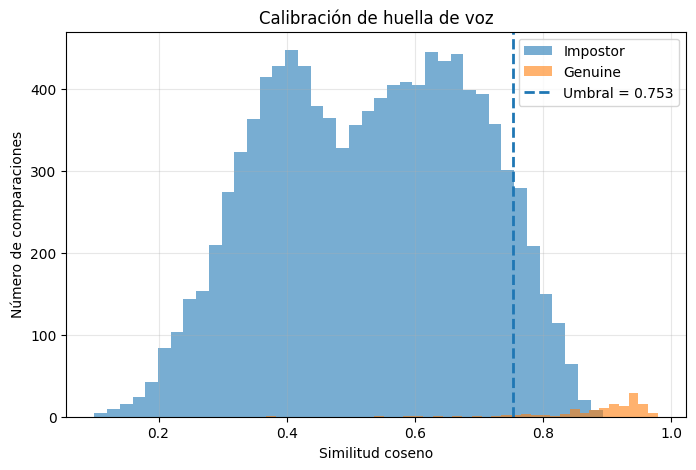

In [36]:
# ============================================================
# CELDA 21 - DISTRIBUCIÓN DE CALIBRACIÓN
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

genuine = calibration_scores[
    calibration_scores["same_identity"].eq(1)
]["similarity"]
impostor = calibration_scores[
    calibration_scores["same_identity"].eq(0)
]["similarity"]

ax.hist(impostor, bins=40, alpha=0.60, label="Impostor")
ax.hist(genuine, bins=40, alpha=0.60, label="Genuine")
ax.axvline(
    OPEN_SET_THRESHOLD,
    linestyle="--",
    linewidth=2,
    label=f"Umbral = {OPEN_SET_THRESHOLD:.3f}",
)
ax.set_title("Calibración de huella de voz")
ax.set_xlabel("Similitud coseno")
ax.set_ylabel("Número de comparaciones")
ax.legend()
ax.grid(True, alpha=0.3)

save_figure_checkpoint(
    fig,
    FIGURES_DIR / "voiceprint_calibration_similarity_distribution.png",
)
plt.show()


[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/figures/open_set_best_similarity_known_vs_unknown.png
[FIGURE] /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/figures/open_set_best_similarity_known_vs_unknown.png


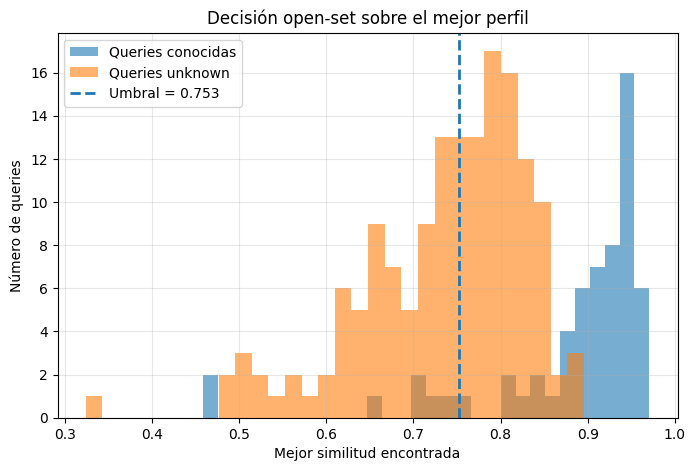

In [37]:
# ============================================================
# CELDA 22 - KNOWN VS UNKNOWN
# ============================================================

fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    known_rows["best_similarity"].dropna(),
    bins=30,
    alpha=0.60,
    label="Queries conocidas",
)
ax.hist(
    unknown_rows["best_similarity"].dropna(),
    bins=30,
    alpha=0.60,
    label="Queries unknown",
)
ax.axvline(
    OPEN_SET_THRESHOLD,
    linestyle="--",
    linewidth=2,
    label=f"Umbral = {OPEN_SET_THRESHOLD:.3f}",
)
ax.set_title("Decisión open-set sobre el mejor perfil")
ax.set_xlabel("Mejor similitud encontrada")
ax.set_ylabel("Número de queries")
ax.legend()
ax.grid(True, alpha=0.3)

save_figure_checkpoint(
    fig,
    FIGURES_DIR / "open_set_best_similarity_known_vs_unknown.png",
)
plt.show()


[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/figures/voiceprint_calibration_roc.png
[FIGURE] /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/figures/voiceprint_calibration_roc.png


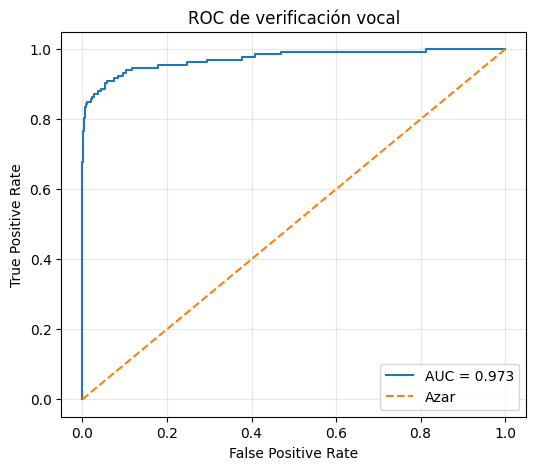

In [38]:
# ============================================================
# CELDA 23 - CURVA ROC
# ============================================================

y_true_calibration = calibration_scores["same_identity"].astype(int).to_numpy()
score_values_calibration = calibration_scores["similarity"].astype(float).to_numpy()

fpr, tpr, _ = roc_curve(y_true_calibration, score_values_calibration)
auc_value = roc_auc_score(y_true_calibration, score_values_calibration)

fig, ax = plt.subplots(figsize=(6, 5))
ax.plot(fpr, tpr, label=f"AUC = {auc_value:.3f}")
ax.plot([0, 1], [0, 1], linestyle="--", label="Azar")
ax.set_title("ROC de verificación vocal")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend()
ax.grid(True, alpha=0.3)

save_figure_checkpoint(
    fig,
    FIGURES_DIR / "voiceprint_calibration_roc.png",
)
plt.show()


In [39]:
# ============================================================
# CELDA 24 - RESUMEN Y MANIFEST DE FINALIZACIÓN
# ============================================================

summary_rows = [
    {"metric": "segmentos_candidatos", "value": len(df_voiceprint_segments)},
    {"metric": "muestras_audio_persona", "value": len(df_samples_open_set)},
    {
        "metric": "agentes_elegibles",
        "value": int(
            identity_summary_open_set[
                identity_summary_open_set["role_proxy"].eq("AGENT")
                & identity_summary_open_set["eligible_profile"].astype(bool)
            ]["person_id"].nunique()
        ),
    },
    {
        "metric": "clientes_elegibles",
        "value": int(
            identity_summary_open_set[
                identity_summary_open_set["role_proxy"].eq("CLIENT")
                & identity_summary_open_set["eligible_profile"].astype(bool)
            ]["person_id"].nunique()
        ),
    },
    {"metric": "umbral_aceptacion", "value": OPEN_SET_THRESHOLD},
    {"metric": "auc_calibracion", "value": open_set_threshold_info["calibration_auc"]},
    {"metric": "eer_calibracion", "value": open_set_threshold_info["eer"]},
    {
        "metric": "known_identification_rate",
        "value": identification_metrics["known_identification_rate"],
    },
    {
        "metric": "unknown_rejection_rate",
        "value": identification_metrics["unknown_rejection_rate"],
    },
    {
        "metric": "open_set_accuracy",
        "value": identification_metrics["overall_open_set_accuracy"],
    },
    {
        "metric": "perfiles_operacionales_agentes",
        "value": len(agent_profiles_operational),
    },
    {
        "metric": "perfiles_operacionales_clientes",
        "value": len(client_profiles_operational),
    },
]

df_open_set_final_summary = pd.DataFrame(summary_rows)

FINAL_SUMMARY_PATH = (
    VOICEPRINT_DIR / "voiceprint_open_set_final_summary.csv"
)
save_dataframe_checkpoint(
    df_open_set_final_summary,
    FINAL_SUMMARY_PATH,
)

required_final_outputs = [
    AGENT_PROFILES_OPERATIONAL_PATH,
    THRESHOLD_CHECKPOINT,
    MODEL_METADATA_PATH,
    OPEN_SET_PREDICTIONS_PATH,
    IDENTIFICATION_METRICS_PATH,
    VERIFICATION_METRICS_PATH,
]

missing_final_outputs = [
    str(path)
    for path in required_final_outputs
    if not Path(path).exists()
]

run_manifest = {
    "status": "completed" if not missing_final_outputs else "incomplete",
    "completed_at_utc": utc_now_iso(),
    "notebook_version": NOTEBOOK_VERSION,
    "config_hash": model_metadata["config_hash"],
    "required_outputs": [str(path) for path in required_final_outputs],
    "missing_outputs": missing_final_outputs,
    "summary": {
        row["metric"]: row["value"]
        for row in summary_rows
    },
}

RUN_MANIFEST_PATH = (
    VOICEPRINT_DIR / "_SUCCESS_voiceprint_open_set.json"
)
save_json_checkpoint(
    run_manifest,
    RUN_MANIFEST_PATH,
)

display(df_open_set_final_summary)

print("\nArchivos principales para el notebook de inferencia:")
print("1.", AGENT_PROFILES_OPERATIONAL_PATH)
print("2.", THRESHOLD_CHECKPOINT)
print("3.", MODEL_METADATA_PATH)
print("4.", RUN_MANIFEST_PATH)

# Sincronización final completa: CSV, JSON, checkpoints y figuras.
uploaded_gcs_files = upload_directory_to_gcs(VOICEPRINT_DIR)

print(
    "\nSincronización final con GCS completada:",
    len(uploaded_gcs_files),
    "archivos.",
)
print(
    "Destino:",
    f"gs://{GCS_BUCKET_NAME}/{GCS_PROJECT_PREFIX}/",
)



[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/voiceprint_open_set_final_summary.csv
[CHECKPOINT] /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/voiceprint_open_set_final_summary.csv | 12 filas
[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/_SUCCESS_voiceprint_open_set.json
[CHECKPOINT] /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/_SUCCESS_voiceprint_open_set.json


,metric,value
0,segmentos_candidatos,24487.000000
1,muestras_audio_persona,2322.000000
2,agentes_elegibles,143.000000
3,clientes_elegibles,22.000000
4,umbral_aceptacion,0.752867
5,auc_calibracion,0.972527
6,eer_calibracion,0.083135
7,known_identification_rate,0.836066
8,unknown_rejection_rate,0.500000
9,open_set_accuracy,0.595349



Archivos principales para el notebook de inferencia:
1. /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/agent_profiles_operational.csv
2. /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/voiceprint_thresholds.json
3. /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/voiceprint_model_metadata.json
4. /home/jupyter/TFM_ProcesadoDeAudios/data/voiceprint_outputs/_SUCCESS_voiceprint_open_set.json
[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/_SUCCESS_voiceprint_open_set.json
[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/agent_profiles_operational.csv
[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/checkpoints/04_voiceprint_identity_partition.json
[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/procesados_UNAV/voiceprint_outputs/checkpoints/04_voiceprint_open_set_split.csv
[GCS-UPLOAD] gs://catedras_audio_detection/pipelineA/proces